<a href="https://colab.research.google.com/github/Ronaldo-Junior1/analise-dados-supermercado/blob/main/Analise_base_supermercado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dicionário das variáveis**

* **Row_ID** : Identificador único de cada linha
* **Order_ID** : Identificador único do pedido
* **Order_Date** : Data do pedido
* **Ship_Date** : Data de envio do pedido
* **Ship_Mode** : Modalidade de envio escolhida
* **Customer_ID** : Identificador único do cliente
* **Customer_Name** : Nome do cliente
* **Segment** : Segmento de mercado do cliente
* **Country** : País do cliente
* **City** : Cidade do cliente
* **State** : Estado do cliente
* **Postal_Code** :  Código postal
* **Region** : Região do cliente
* **Product_ID** : Identificador do produto
* **Category** : Categoria do produto
* **Sub_Category** : Subcategoria do produto
* **Product Name** : Nome do produto
* **Sales** : Valor de venda
* **Quantity** : Quantidade vendida
* **Discount** : Desconto aplicado
* **Profit** : Lucro ou prejuízo da venda

In [1]:
# importar os pacotes necessarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", palette='rocket')
#sns.color_palette("flare", as_cmap=True)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Analise_dados"

Mounted at /content/drive


In [4]:
column_names = [
    'Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode' , 'Customer_ID',
    'Customer_Name', 'Segment', 'Country', 'City', 'State',
    'Postal_Code', 'Region', 'Product_ID', 'Category',
    'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount',
    'Profit'
]
df = pd.read_csv(f'{path}/01_supermercados.csv', names=column_names, header=0,encoding='latin1')
df.head(10)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


Verificando a quantidade de entradas em nosso Dataset e quantas variáveis/colunas existem nele

In [5]:
#. Exibindo a quantiade de dados inseridos e a quantidade de colunas/variáveis
df.shape

(9994, 21)

Exibindo os dados estatísticos do Dataset para obter uma análise prévia dos dados

In [6]:
#. Exibindo os dados estatísticos do Dataset
df.describe()

,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


*É* possível observar uma discrepância nos dados de Sales, Quantity, Discount e Profit. Onde a média dessas variáveis é, respectivamente, $229, ~3, ~15% e ~28.
- Porém, os maiores valores são, respectivamente, ~22638, 14, 80% e ~8399. O que é estranho, tendo em vista que, respectivamente, 75% dos dados estão abaixo de ~209, 5, 20% e 29.
- Além disso, também é possível observar que a coluna "Profit" possui tanto um extremo mínimo, ~ -6599 e um extremo positivo que é o valor máximo.

Verificando o tipo das variáveis para analisar se as variáveis estão com o seu tipo adequado para sua devida finalidade

In [7]:
#. Exibindo o tipo de cada variável
df.dtypes

,0
Row_ID,int64
Order_ID,object
Order_Date,object
Ship_Date,object
Ship_Mode,object
Customer_ID,object
Customer_Name,object
Segment,object
Country,object
City,object


Aparentemente todas as variáveis estão com seus tipos corretos

Verificando se o Dataset possui valores ausentes, o que pode afetar a análise dos dados

In [8]:
#. Exibindo os valores ausente do Datase em ordem decrescente
((df.isnull().sum() / df.shape[0])*100).sort_values(ascending=False)

,0
Row_ID,0.0
Order_ID,0.0
Order_Date,0.0
Ship_Date,0.0
Ship_Mode,0.0
Customer_ID,0.0
Customer_Name,0.0
Segment,0.0
Country,0.0
City,0.0


Não há nenhum valor ausente em nosso Dataset

Verificando qual o tipo de Distribuição das variáveis númericas do Dataset

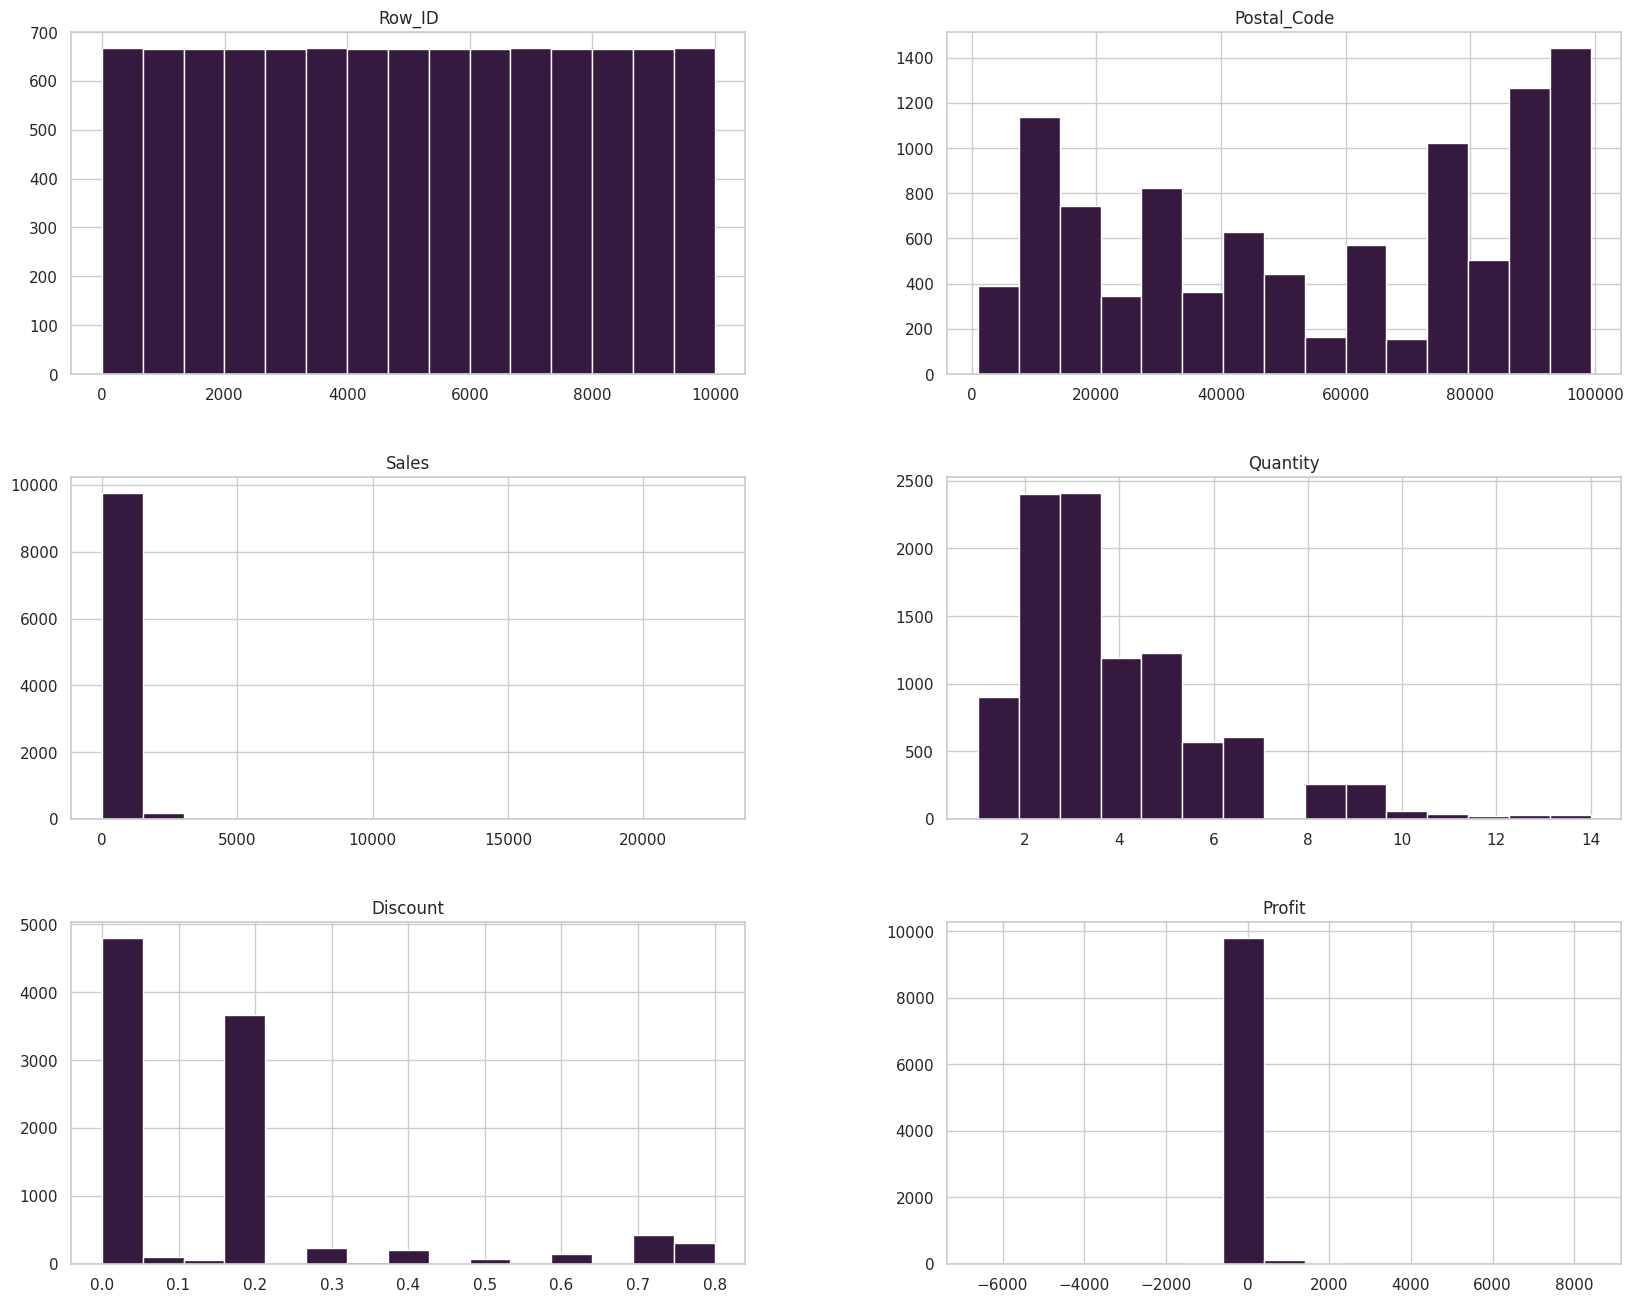

In [9]:
#. Plotando os histogramas das variáveis numéricas
df.hist(bins=15, figsize=(20,16));

- A distribuição de dados para as variáveis Sales e Profit indica que há valores muito discrepantes nos dados
- A distibuição para Discount também não é muito uniforme
- A Distribuição para a variável Quantity tem um perfil mais normal de distribuição.

Verificando a margem de lucro por Produto e Segmento

In [10]:
#. Descobrindo a margem de lucro por produto
productProfit = df.groupby('Product_Name').Profit.mean()
print(productProfit.sort_values(ascending=False))

Product_Name
Canon imageCLASS 2200 Advanced Copier                                    5039.985600
Canon imageCLASS MF7460 Monochrome Digital Laser Multifunction Copier    1995.990000
Ativa V4110MDD Micro-Cut Shredder                                        1886.473050
3D Systems Cube Printer, 2nd Generation, Magenta                         1858.985700
Zebra ZM400 Thermal Label Printer                                        1671.768000
                                                                            ...     
Zebra GK420t Direct Thermal/Thermal Transfer Printer                     -938.280000
Lexmark MX611dhe Monochrome Laser Printer                               -1147.493250
Cisco TelePresence System EX90 Videoconferencing Unit                   -1811.078400
Cubify CubeX 3D Printer Double Head Print                               -2959.990133
Cubify CubeX 3D Printer Triple Head Print                               -3839.990400
Name: Profit, Length: 1850, dtype: float64


In [11]:
#. Descobrindo a margem de lucro por Segmento de cliente
segmentProfit = df.groupby('Segment').Profit.mean()
print(segmentProfit.sort_values(ascending=False))

Segment
Home Office    33.818664
Corporate      30.456667
Consumer       25.836873
Name: Profit, dtype: float64


In [12]:
#. Descobrindo a margem de lucro por Segmento de produto
segmentProfit = df.groupby('Category').Profit.mean()
print(segmentProfit.sort_values(ascending=False))

Category
Technology         78.752002
Office Supplies    20.327050
Furniture           8.699327
Name: Profit, dtype: float64


Agora vamos analisar a distribuição de lucro por categoria de produto.

/tmp/ipykernel_9256/3330741135.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Profit', palette='rocket')


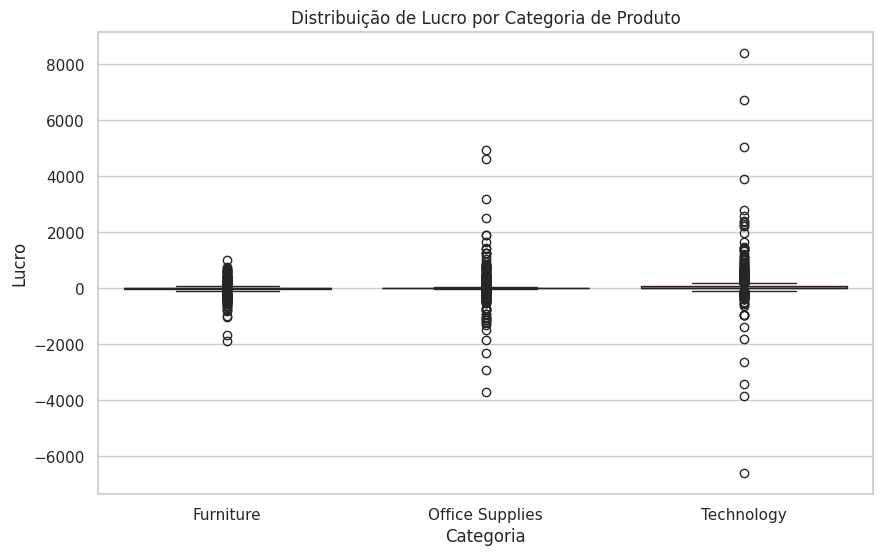

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Profit', palette='rocket')
plt.title('Distribuição de Lucro por Categoria de Produto')
plt.xlabel('Categoria')
plt.ylabel('Lucro')
plt.show()

Para melhor visualização das caixas, sem outliers

/tmp/ipykernel_9256/4218507399.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Profit', palette='rocket', showfliers=False)


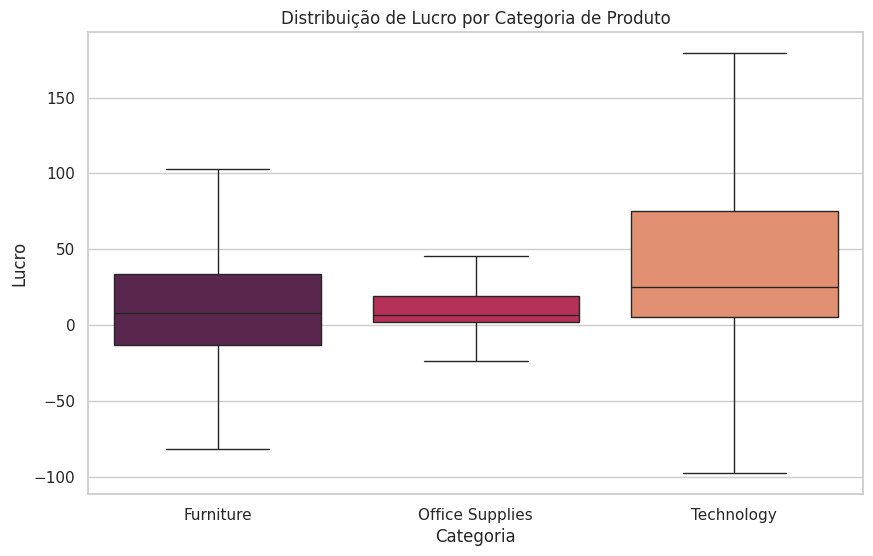

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Profit', palette='rocket', showfliers=False)
plt.title('Distribuição de Lucro por Categoria de Produto')
plt.xlabel('Categoria')
plt.ylabel('Lucro')
plt.show()

Tendo isso em vista, vamos verificar quais produtos específicos dão mais prejuízo e quais dão mais lucro dentro dessas categorias.

In [15]:
colunas_foco = ['Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit']
maiores_lucros_cat = df.nlargest(10, 'Profit')[colunas_foco]
maiores_prejuizos_cat = df.nsmallest(10, 'Profit')[colunas_foco]

print("Maiores Prejuízos por Categoria:")
display(maiores_prejuizos_cat)

print("\nMaiores Lucros por Categoria:")
display(maiores_lucros_cat)

Maiores Prejuízos por Categoria:


,Category,Product_Name,Sales,Quantity,Discount,Profit
7772,Technology,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
683,Technology,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
9774,Office Supplies,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
3011,Technology,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800
4991,Office Supplies,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845
3151,Technology,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912
5310,Office Supplies,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820
9639,Furniture,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124
1199,Office Supplies,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464
2697,Technology,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784



Maiores Lucros por Categoria:


,Category,Product_Name,Sales,Quantity,Discount,Profit
6826,Technology,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,Technology,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
4190,Technology,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,Office Supplies,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,Office Supplies,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
2623,Technology,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
509,Office Supplies,Fellowes PB500 Electric Punch Plastic Comb Bin...,6354.950,5,0.0,3177.4750
8488,Technology,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
7666,Technology,Hewlett Packard LaserJet 3310 Copier,5399.910,9,0.0,2591.9568
6520,Office Supplies,GBC DocuBind P400 Electric Binding System,5443.960,4,0.0,2504.2216


Agora, para entender o motivo desses prejuízos gigantes (como o de -6599), geralmente a causa está associada a altos descontos (Discount). Então vamos verificar se esse é um comportamento comum, onde os maiores prejuizos são nas maiores quantidades de desconto.

In [16]:
# Filtrando as vendas com prejuízo pior que -1000
outliers_negativos = df[df['Profit'] < -1000]

colunas_interesse = ['Product_Name', 'Segment', 'Category', 'Sales', 'Quantity', 'Discount', 'Profit']
outliers_negativos[colunas_interesse].sort_values(by='Profit').head(30)

,Product_Name,Segment,Category,Sales,Quantity,Discount,Profit
7772,Cubify CubeX 3D Printer Double Head Print,Consumer,Technology,4499.985,5,0.7,-6599.9780
683,Cubify CubeX 3D Printer Triple Head Print,Corporate,Technology,7999.980,4,0.5,-3839.9904
9774,GBC DocuBind P400 Electric Binding System,Consumer,Office Supplies,2177.584,8,0.8,-3701.8928
3011,Lexmark MX611dhe Monochrome Laser Printer,Home Office,Technology,2549.985,5,0.7,-3399.9800
4991,Ibico EPK-21 Electric Binding System,Corporate,Office Supplies,1889.990,5,0.8,-2929.4845
3151,Cubify CubeX 3D Printer Double Head Print,Consumer,Technology,1799.994,2,0.7,-2639.9912
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,Consumer,Office Supplies,1525.188,6,0.8,-2287.7820
9639,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Consumer,Furniture,4297.644,13,0.4,-1862.3124
1199,GBC DocuBind P400 Electric Binding System,Consumer,Office Supplies,1088.792,4,0.8,-1850.9464
2697,Cisco TelePresence System EX90 Videoconferenci...,Home Office,Technology,22638.480,6,0.5,-1811.0784


Dos maiores prejuízos listados, a grande maioria foi causada por descontos de 0.7 (70%) e 0.8 (80%).

O maior prejuízo de todos (-6.599,97) ocorreu em uma venda de impressoras 3D com 70% de desconto.

Os Binding Systemsaparecem várias vezes dando prejuízos entre -1.000 e -3.700, quase todos com 80% de desconto.

O problema afeta produtos de alto valor agregado no caso tecnologia
Dar 80% de desconto em uma caneta gera um prejuízo de centavos. Mas a tabela mostra que a empresa está dando 50% a 70% de desconto em produtos caríssimos, como Impressoras 3D, Impressoras a Laser e Sistemas de Videoconferência.

A venda do sistema Cisco gerou 22.638 em receita, mas como teve 50% de desconto, resultou em um prejuízo de -1.811. Isso indica que a margem original do produto não suporta um corte de preço dessa magnitude.

Quando o desconto é alto, o cliente tende a comprar mais. Veja a mesa de conferência (Chromcraft): a empresa vendeu 13 unidades com 40% de desconto. O resultado foi um prejuízo de -1.862.

In [17]:
# Filtrando as vendas com lucro maior que 1000
outliers_positivos = df[df['Profit'] > 1000]

outliers_positivos[colunas_interesse].sort_values(by='Profit').tail(30)

,Product_Name,Segment,Category,Sales,Quantity,Discount,Profit
994,Fellowes PB300 Plastic Comb Binding Machine,Corporate,Office Supplies,2715.930,7,0.0,1276.4871
6340,"3D Systems Cube Printer, 2nd Generation, Magenta",Corporate,Technology,5199.960,4,0.0,1351.9896
5126,Ativa V4110MDD Micro-Cut Shredder,Consumer,Technology,2799.960,4,0.0,1371.9804
515,Canon Image Class D660 Copier,Home Office,Technology,2999.950,5,0.0,1379.9770
353,GBC DocuBind P400 Electric Binding System,Home Office,Office Supplies,4355.168,4,0.2,1415.4296
4093,Cisco 9971 IP Video Phone Charcoal,Consumer,Technology,3080.000,7,0.0,1416.8000
5562,Hewlett Packard LaserJet 3310 Copier,Corporate,Technology,2999.950,5,0.0,1439.9760
9270,GBC DocuBind TL300 Electric Binding System,Consumer,Office Supplies,4305.552,6,0.2,1453.1238
1454,Hewlett-Packard Deskjet 3050a All-in-One Color...,Corporate,Technology,3040.000,8,0.0,1459.2000
1644,Canon PC940 Copier,Corporate,Technology,3149.930,7,0.0,1480.4671


Dos maiores lucros listados, a esmagadora maioria foi alcançada com desconto zero (0%). O maior lucro de todos (8.399,97) ocorreu em uma venda de copiadoras avançadas com 0% de desconto e receita de 17.499.

O equipamento Canon imageCLASS 2200 Advanced Copier aparece quatro vezes dominando a lista, o que prova que os produtos de alto valor agregado no segmento de Tecnologia possuem uma margem excelente quando o preço original é mantido. As informações batem perfeitamente com a análise de prejuízos, comprovando que o problema definitivamente não está nos produtos em si, mas na política agressiva de preços.

Os mesmos Sistemas de Encadernação (Binding Systems) que afundaram o caixa com prejuízos de até -3.700 sob 80% de desconto, aparecem agora como os maiores lucros, gerando de 4.946, 4.630 e 2.504 quando vendidos a preço cheio.

A lógica do volume também se confirma, agindo agora como um multiplicador positivo: quando o cliente compra em grande quantidade sem a aplicação de descontos altos, o retorno financeiro aumenta.

O modelo GBC Ibimaster 500 exemplifica isso muito bem, com a venda de 13 unidades a 0% de desconto gerando o quarto maior lucro geral. A base mostra que a estrutura de custos da loja é sólida e os produtos são rentáveis por natureza, suportando no máximo um corte brando, já que o único desconto presente nesse top 10 foi de 20% em uma das vendas da Canon, que ainda conseguiu preservar um lucro robusto de 3.919.

Agora vamos analisar a distribuição de lucro por categoria de produto.

/tmp/ipykernel_9256/3262116431.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Segment', y='Profit', palette='rocket')


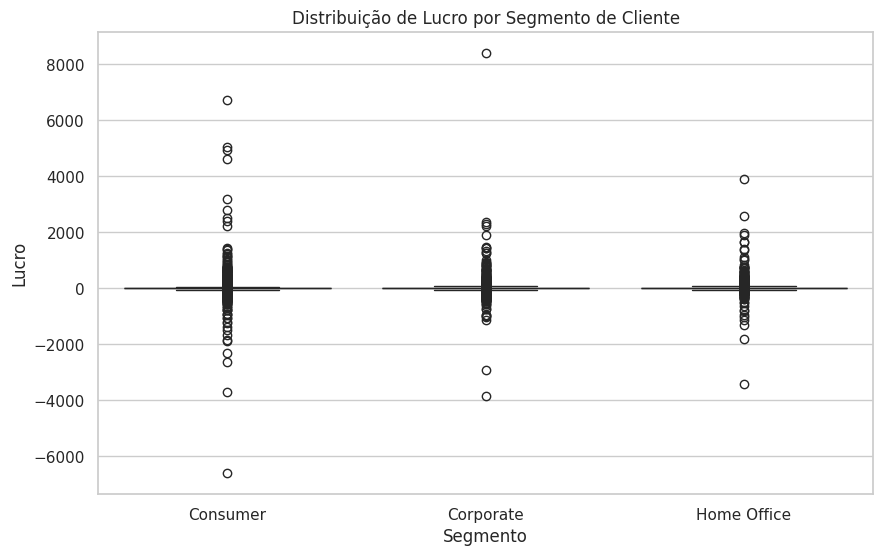

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Segment', y='Profit', palette='rocket')
plt.title('Distribuição de Lucro por Segmento de Cliente')
plt.xlabel('Segmento')
plt.ylabel('Lucro')
plt.show()

Para melhor visualização das caixas, sem os outliers

/tmp/ipykernel_9256/3119542081.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Segment', y='Profit', palette='rocket', showfliers=False)


<Axes: xlabel='Segment', ylabel='Profit'>

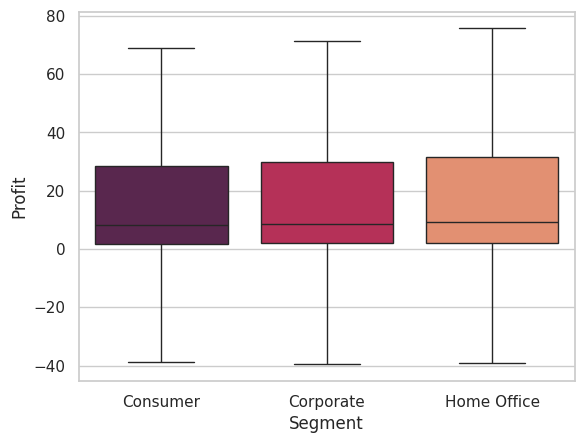

In [19]:
sns.boxplot(data=df, x='Segment', y='Profit', palette='rocket', showfliers=False)

Tendo isso em vista, vamos verificar quais produtos específicos dão mais prejuízo e quais dão mais lucro dentro dessas categorias.

In [20]:
colunas_foco_seg = ['Segment', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit']
maiores_lucros_seg = df.nlargest(10, 'Profit')[colunas_foco_seg]
maiores_prejuizos_seg = df.nsmallest(10, 'Profit')[colunas_foco_seg]

print("Maiores Prejuízos por Segmento:")
display(maiores_prejuizos_seg)

print("\nMaiores Lucros por Segmento:")
display(maiores_lucros_seg)

Maiores Prejuízos por Segmento:


,Segment,Product_Name,Sales,Quantity,Discount,Profit
7772,Consumer,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
683,Corporate,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
9774,Consumer,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
3011,Home Office,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800
4991,Corporate,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845
3151,Consumer,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912
5310,Consumer,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820
9639,Consumer,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124
1199,Consumer,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464
2697,Home Office,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784



Maiores Lucros por Segmento:


,Segment,Product_Name,Sales,Quantity,Discount,Profit
6826,Corporate,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,Consumer,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
4190,Consumer,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,Consumer,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,Consumer,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
2623,Home Office,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
509,Consumer,Fellowes PB500 Electric Punch Plastic Comb Bin...,6354.950,5,0.0,3177.4750
8488,Consumer,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
7666,Home Office,Hewlett Packard LaserJet 3310 Copier,5399.910,9,0.0,2591.9568
6520,Consumer,GBC DocuBind P400 Electric Binding System,5443.960,4,0.0,2504.2216


Agora vamos analisar o volume de saída dos produtos, agrupando as informações para identificar os 5 itens mais vendidos dentro de cada categoria. Isso demonstra onde está o maior giro do estoque.

In [21]:
# Agrupando por Categoria e Produto, somando a Quantidade vendida
vendas_categoria = df.groupby(['Category', 'Product_Name'])['Quantity'].sum().reset_index()

# Ordenando do maior para o menor e filtrando os 5 primeiros de cada categoria
top5_categoria = vendas_categoria.sort_values(['Category', 'Quantity'], ascending=[True, False]).groupby('Category').head(5)

print("Top 5 Produtos Mais Vendidos por Categoria:")
display(top5_categoria)

Top 5 Produtos Mais Vendidos por Categoria:


,Category,Product_Name,Quantity
257,Furniture,KI Adjustable-Height Table,74
351,Furniture,"Situations Contoured Folding Chairs, 4/Set",64
355,Furniture,Staple-based wall hangings,62
66,Furniture,Chromcraft Round Conference Tables,61
140,Furniture,Eldon Wave Desk Accessories,61
1149,Office Supplies,Staples,215
1144,Office Supplies,Staple envelope,170
722,Office Supplies,Easy-staple paper,150
1150,Office Supplies,Staples in misc. colors,86
585,Office Supplies,Avery Non-Stick Binders,71


In [22]:
# 1. Agrupando por Categoria e Produto, somando o Lucro Total
lucro_produto_cat = df.groupby(['Category', 'Product_Name'])['Profit'].sum().reset_index()

# 2. Ordenando do maior para o menor e filtrando os 5 mais lucrativos de cada categoria
top5_lucro_cat = lucro_produto_cat.sort_values(['Category', 'Profit'], ascending=[True, False]).groupby('Category').head(5)

print("Top 5 Produtos Mais Lucrativos por Categoria:")
display(top5_lucro_cat)

Top 5 Produtos Mais Lucrativos por Categoria:


,Category,Product_Name,Profit
225,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",1927.4420
175,Furniture,Global Deluxe High-Back Manager's Chair,1558.5910
238,Furniture,Hon Pagoda Stacking Chairs,1540.7040
217,Furniture,Hon 4070 Series Pagoda Armless Upholstered Sta...,1388.6348
313,Furniture,Office Star - Professional Matrix Back Chair w...,1305.6456
775,Office Supplies,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
891,Office Supplies,Ibico EPK-21 Electric Binding System,3345.2823
870,Office Supplies,Honeywell Enviracaire Portable HEPA Air Cleane...,3247.0200
774,Office Supplies,Fellowes PB300 Plastic Comb Binding Machine,2518.0551
893,Office Supplies,Ibico Ibimaster 300 Manual Binding System,2318.3370


/tmp/ipykernel_9256/1846363528.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=dados_cat, x='Quantity', y='Product_Name', palette='viridis')
/tmp/ipykernel_9256/1846363528.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=dados_cat, x='Quantity', y='Product_Name', palette='viridis')
/tmp/ipykernel_9256/1846363528.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=dados_cat, x='Quantity', y='Product_Name', palette='viridis')
/tmp/ipykernel_9256/1846363528.py:11: UserWarning: Tight layo

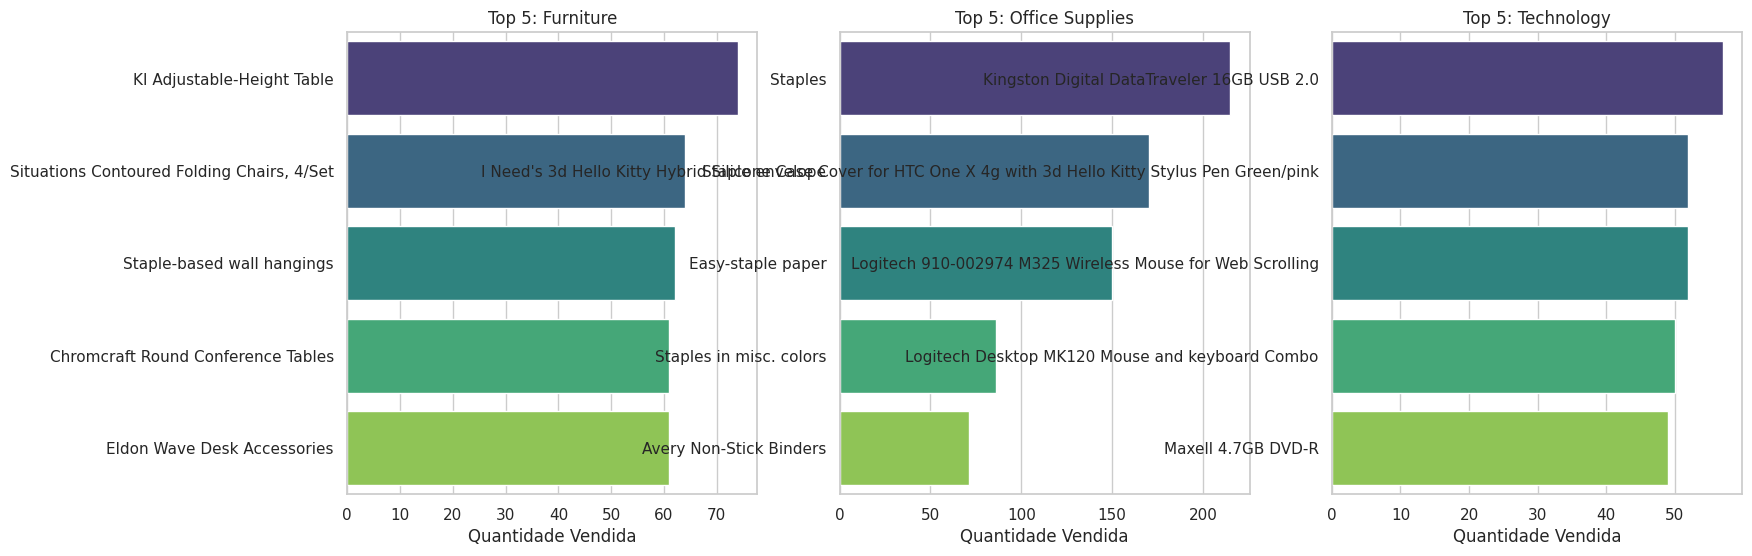

In [23]:
categorias = top5_categoria['Category'].unique()
fig, axes = plt.subplots(1, len(categorias), figsize=(18, 6))

for i, cat in enumerate(categorias):
    dados_cat = top5_categoria[top5_categoria['Category'] == cat]
    sns.barplot(ax=axes[i], data=dados_cat, x='Quantity', y='Product_Name', palette='viridis')
    axes[i].set_title(f'Top 5: {cat}')
    axes[i].set_xlabel('Quantidade Vendida')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Agora vamos analisar a mesma métrica de giro de estoque, mas filtrando os 5 produtos mais vendidos dentro de cada segmento de cliente. Isso nos mostra se o comportamento de compra muda dependendo do perfil.

In [24]:
# Agrupando por Segmento e Produto, somando a Quantidade vendida
vendas_segmento = df.groupby(['Segment', 'Product_Name','Category'])['Quantity'].sum().reset_index()

# Ordenando do maior para o menor e filtrando os 5 primeiros de cada segmento
top5_segmento = vendas_segmento.sort_values(['Segment', 'Quantity'], ascending=[True, False]).groupby('Segment').head(5)

print("Top 5 Produtos Mais Vendidos por Segmento:")
display(top5_segmento)

Top 5 Produtos Mais Vendidos por Segmento:


,Segment,Product_Name,Category,Quantity
1373,Consumer,Staple envelope,Office Supplies,104
1378,Consumer,Staples,Office Supplies,97
1379,Consumer,Staples in misc. colors,Office Supplies,75
1388,Consumer,Storex Dura Pro Binders,Office Supplies,61
492,Consumer,Easy-staple paper,Office Supplies,60
2887,Corporate,Staples,Office Supplies,90
2881,Corporate,Staple envelope,Office Supplies,63
2119,Corporate,Easy-staple paper,Office Supplies,44
2300,Corporate,"Global High-Back Leather Tilter, Burgundy",Furniture,32
1765,Corporate,"Acco Pressboard Covers with Storage Hooks, 14 ...",Office Supplies,31


/tmp/ipykernel_9256/4204315781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=dados_seg, x='Quantity', y='Product_Name', palette='magma')
/tmp/ipykernel_9256/4204315781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=dados_seg, x='Quantity', y='Product_Name', palette='magma')
/tmp/ipykernel_9256/4204315781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=dados_seg, x='Quantity', y='Product_Name', palette='magma')


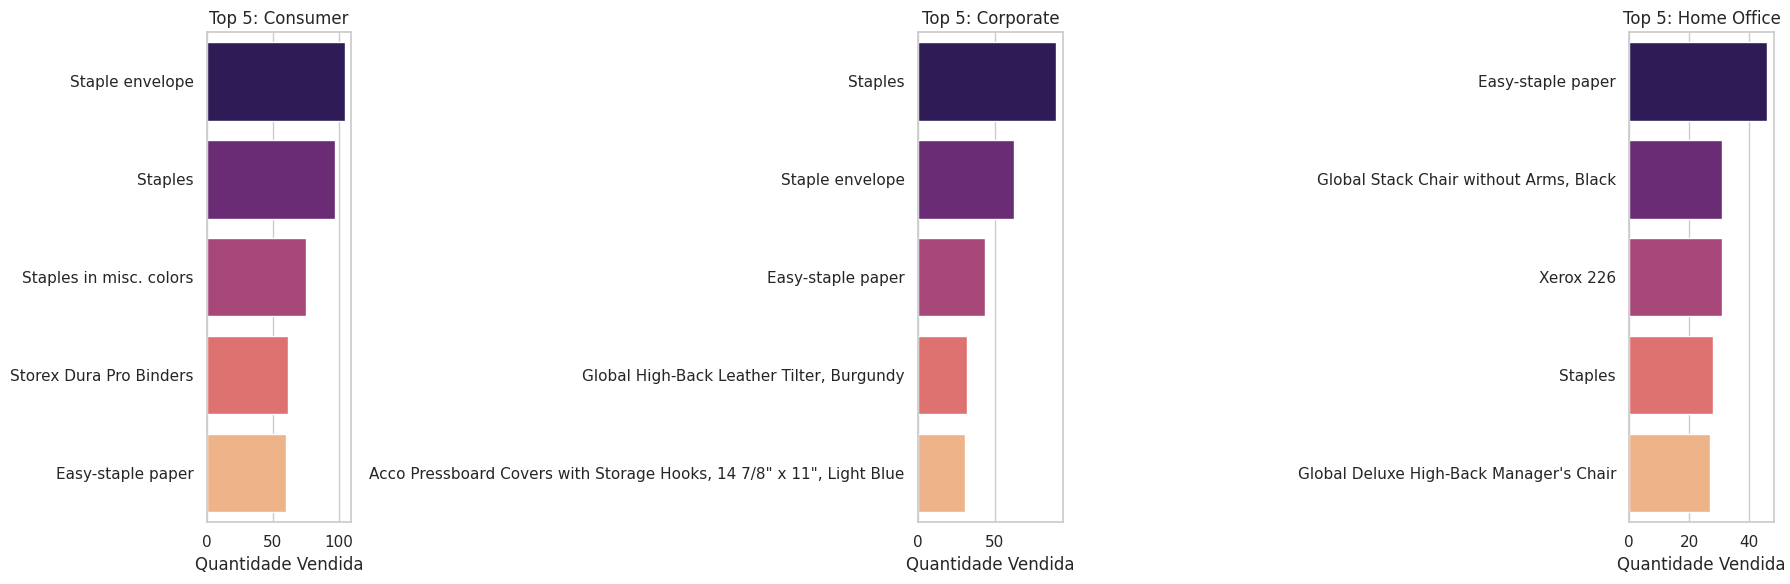

In [25]:
segmentos = top5_segmento['Segment'].unique()
fig, axes = plt.subplots(1, len(segmentos), figsize=(18, 6))

for i, seg in enumerate(segmentos):
    dados_seg = top5_segmento[top5_segmento['Segment'] == seg]
    sns.barplot(ax=axes[i], data=dados_seg, x='Quantity', y='Product_Name', palette='magma')
    axes[i].set_title(f'Top 5: {seg}')
    axes[i].set_xlabel('Quantidade Vendida')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Avançando em nossa análise de comportamento de compra, precisamos entender como a demanda real por produtos se distribui entre os nossos diferentes perfis de clientes. O objetivo agora é mapear o volume de saída do estoque, cruzando as três grandes categorias de produtos (Furniture, Office Supplies e Technology) com os três segmentos que atendemos (Consumer, Corporate e Home Office). Essa visualização macro nos mostrará qual é o carro-chefe de vendas e se o perfil do cliente muda radicalmente o tipo de produto que ele consome.

Volume de Vendas por Categoria dentro de cada Segmento:


,Segment,Category,Quantity
1,Consumer,Office Supplies,11758
0,Consumer,Furniture,4166
2,Consumer,Technology,3597
4,Corporate,Office Supplies,7018
3,Corporate,Furniture,2495
5,Corporate,Technology,2095
7,Home Office,Office Supplies,4130
6,Home Office,Furniture,1367
8,Home Office,Technology,1247


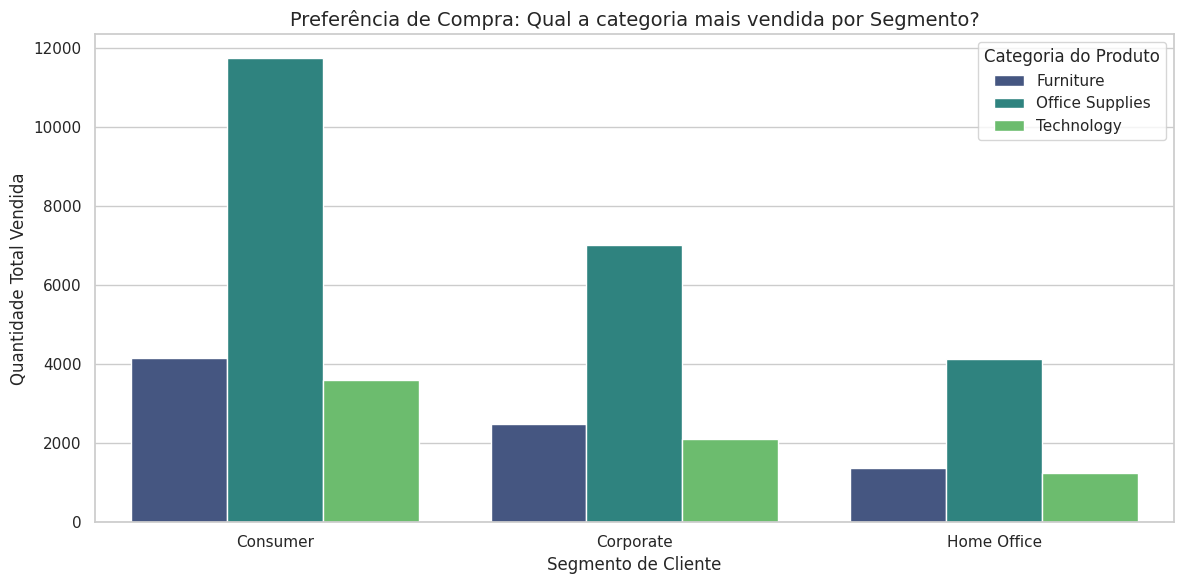

In [26]:
# 1. Agrupando por Segmento e Categoria, somando a Quantidade vendida
vendas_segmento_cat = df.groupby(['Segment', 'Category'])['Quantity'].sum().reset_index()

# 2. Exibindo a tabela organizada do maior para o menor dentro de cada segmento
vendas_ordenadas = vendas_segmento_cat.sort_values(by=['Segment', 'Quantity'], ascending=[True, False])
print("Volume de Vendas por Categoria dentro de cada Segmento:")
display(vendas_ordenadas)

# 3. Plotando o Gráfico Resumo
plt.figure(figsize=(12, 6))

# Usamos o 'hue' para criar barras lado a lado para cada Categoria dentro do Segmento
sns.barplot(data=vendas_segmento_cat, x='Segment', y='Quantity', hue='Category', palette='viridis')

plt.title('Preferência de Compra: Qual a categoria mais vendida por Segmento?', fontsize=14)
plt.xlabel('Segmento de Cliente', fontsize=12)
plt.ylabel('Quantidade Total Vendida', fontsize=12)
plt.legend(title='Categoria do Produto')

plt.tight_layout()
plt.show()

A visualização revela que a categoria de Office Supplies domina o volume de vendas de forma absoluta em todos os segmentos. Esse padrão constante confirma que dependemos desses itens de consumo rápido para garantir o giro de estoque e o fluxo de clientes.

In [27]:
# Agrupando por categoria e somando a quantidade total vendida
volume_por_categoria = df.groupby('Category')['Quantity'].sum().reset_index()

# Ordenando os resultados do maior para o menor volume
volume_por_categoria = volume_por_categoria.sort_values(by='Quantity', ascending=False)

# Exibindo o resultado
print("Total de produtos vendidos por Categoria:")
display(volume_por_categoria)

Total de produtos vendidos por Categoria:


,Category,Quantity
1,Office Supplies,22906
0,Furniture,8028
2,Technology,6939


Com isso, finalizamos a exploração inicial dessa base de dados. Até aqui, analisamos o volume dos itens vendidos, a distribuição entre os segmentos de clientes e como as taxas de desconto afetam a coluna de lucro.

A principal descoberta dos dados está na categoria de Tecnologia. Como vimos nos gráficos, essa categoria concentra os valores mais extremos de todo o dataset. Ela possui os registros com os maiores lucros, mas também contém as linhas com os maiores prejuízos, geralmente associados a descontos muito altos.

Do ponto de vista da análise de dados, o problema é que esses valores são muito atípicos. Ter registros isolados de 8.400 de lucro ou de -6.600 de prejuízo cria fortes distorções matemáticas. Esses extremos, puxam a média da base de forma artificial e acabam mascarando o comportamento "normal" do dataset. Nós vimos isso claramente na visualização dos boxplots, onde a caixa principal ficou completamente espremida porque os outliers esticaram muito a escala do gráfico.

Para termos uma visão estatística mais fiel de como a maior parte dos dados se comporta, não podemos basear a análise em médias distorcidas.

Por isso, o próximo passo essencial para aprofundar esse projeto será aplicar o tratamento desses outliers. A ideia é isolar e retirar temporariamente esses valores discrepantes da base para, então, refazer as visualizações.

# Analise Sazonalidade

In [28]:
# Garantindo o formato de data
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Criando as colunas de Ano e Trimestre
df['Year'] = df['Order_Date'].dt.year
df['Quarter'] = df['Order_Date'].dt.quarter

# Agrupando o Faturamento (Sales) por Ano e Trimestre
vendas_trimestre = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()

# Criando a Tabela Dinâmica (Pivot Table) para facilitar a leitura dos números
tabela_sazonalidade = vendas_trimestre.pivot(index='Year', columns='Quarter', values='Sales')

print("Faturamento Exato por Trimestre e Ano:")
display(tabela_sazonalidade)

Faturamento Exato por Trimestre e Ano:


Quarter,1,2,3,4
Year,,,,
2014,74447.7960,86538.7596,143633.2123,179627.7302
2015,68851.7386,89124.1870,130259.5752,182297.0082
2016,93237.1810,136082.3010,143787.3622,236098.7538
2017,123144.8602,133764.3720,196251.9560,280054.0670


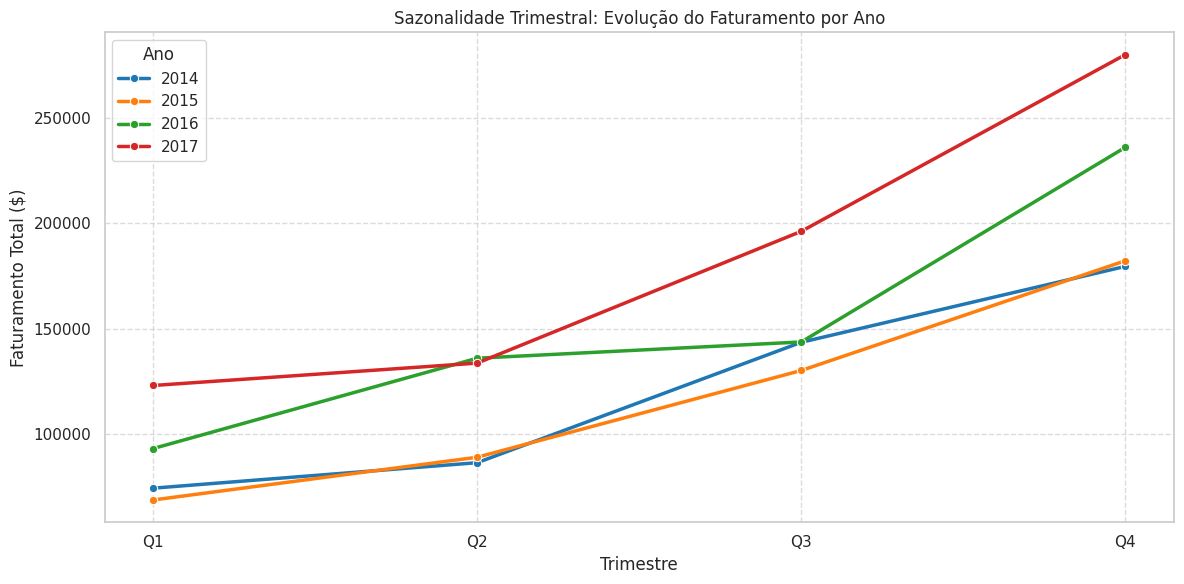

In [29]:
# Plotando o Gráfico de Sazonalidade
plt.figure(figsize=(12, 6))

# O parâmetro 'hue' faz criar uma linha separada para cada ano
sns.lineplot(data=vendas_trimestre, x='Quarter', y='Sales', hue='Year', marker='o', palette='tab10', linewidth=2.5)

plt.title('Sazonalidade Trimestral: Evolução do Faturamento por Ano')
plt.xlabel('Trimestre')
plt.ylabel('Faturamento Total ($)')
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4']) # Renomeando o eixo X
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Ano')

plt.tight_layout()
plt.show()

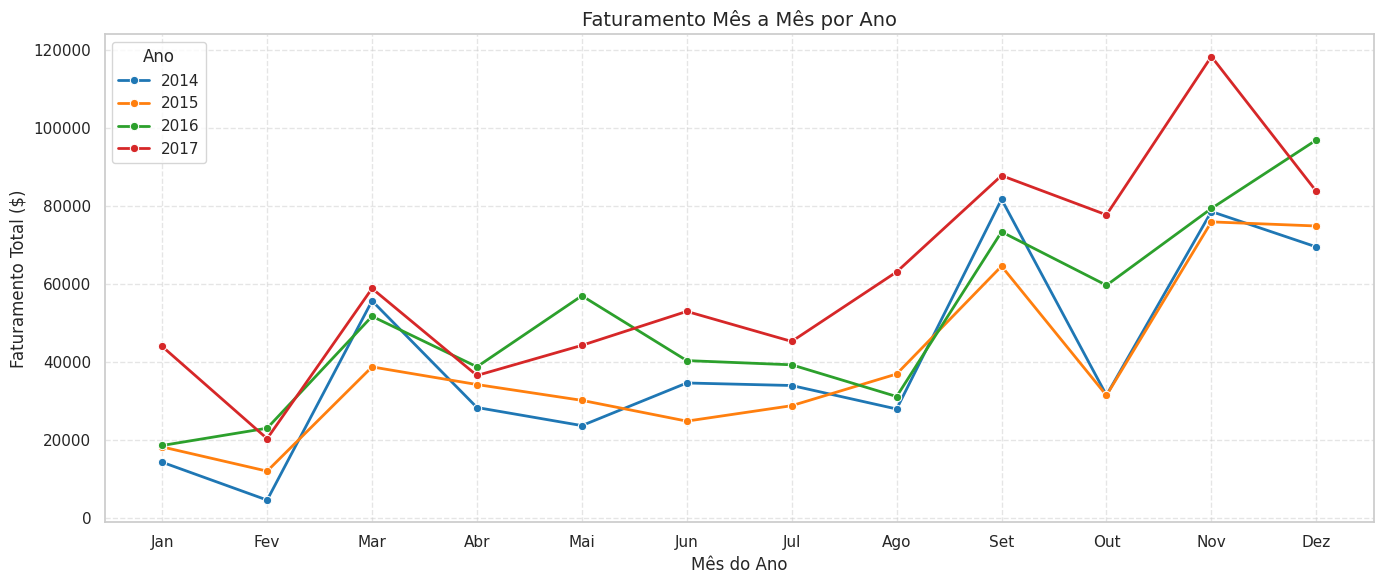

In [30]:
# Garantindo que a coluna Month exista (números de 1 a 12)
df['Month'] = df['Order_Date'].dt.month

# Agrupando as vendas por Ano e Mês
vendas_mensais = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# Plotando o Gráfico de Sazonalidade Mensal
plt.figure(figsize=(14, 6))

# Criando as linhas anuais, mas agora com quebra mês a mês
sns.lineplot(data=vendas_mensais, x='Month', y='Sales', hue='Year', marker='o', palette='tab10', linewidth=2)

plt.title('Faturamento Mês a Mês por Ano', fontsize=14)
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Faturamento Total ($)', fontsize=12)

# Ajustando o eixo X para mostrar os nomes dos meses e facilitar a leitura
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
plt.xticks(range(1, 13), meses_nomes)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Ano')

plt.tight_layout()
plt.show()

Analisando o gráfico de faturamento mês a mês, fica muito claro que o supermercado segue um padrão de vendas que se repete fielmente todos os anos. O primeiro semestre é sempre o período mais fraco, com a minima acontecendo logo em fevereiro, que é o mês com o menor volume de vendas. Esse cenário calmo se arrasta até a metade do ano. Quando chegamos em agosto, os números começam a subir e dão um salto bem visível em setembro, que já funciona como uma preparação para a reta final do ano. O grande destaque, no entanto, é novembro. Esse é, disparado, o mês em que a loja mais vende, formando o ponto mais alto do gráfico, muito provavelmente por causa das compras da época de Black Friday. Um detalhe interessante que a análise revela é que, logo depois desse pico gigantesco, as vendas tendem a cair em dezembro.

Volume de Pedidos por Modo de Envio:


,Ship_Mode,Quantidade_de_Pedidos
0,Standard Class,5968
1,Second Class,1945
2,First Class,1538
3,Same Day,543


/tmp/ipykernel_9256/3902323493.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=volume_por_frete, x='Ship_Mode', y='Quantidade_de_Pedidos', palette='Blues_r')


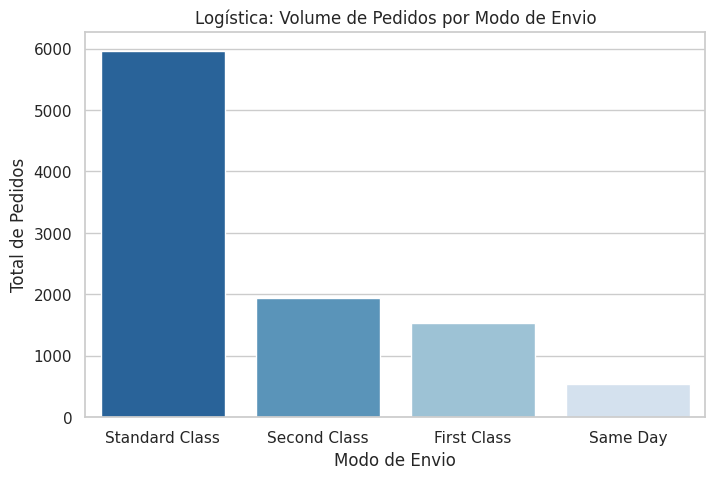

In [31]:
# Garantindo que as colunas de data estão no formato correto
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

# Criando a coluna de Tempo de Entrega (em dias)
df['Delivery_Time'] = (df['Ship_Date'] - df['Order_Date']).dt.days

# Analisando a popularidade dos Modos de Envio (Ship Mode)
volume_por_frete = df['Ship_Mode'].value_counts().reset_index()
volume_por_frete.columns = ['Ship_Mode', 'Quantidade_de_Pedidos']

print("Volume de Pedidos por Modo de Envio:")
display(volume_por_frete)

# Gráfico do volume de envios
plt.figure(figsize=(8, 5))
sns.barplot(data=volume_por_frete, x='Ship_Mode', y='Quantidade_de_Pedidos', palette='Blues_r')
plt.title('Logística: Volume de Pedidos por Modo de Envio')
plt.xlabel('Modo de Envio')
plt.ylabel('Total de Pedidos')
plt.show()

A esmagadora maioria dos clientes escolhe o Standard Class (Entrega Padrão), enquanto modalidades expressas como Same Day (Mesmo Dia) têm um volume irrelevante. Isso é uma excelente notícia para a saúde financeira do negócio. Como o cliente não exige entregas urgentes, a loja tem uma janela confortável (de 4 a 5 dias) para consolidar cargas, fechar rotas eficientes e evitar o despacho de veículos vazios apenas para cumprir prazos agressivos.

/tmp/ipykernel_9256/3570209294.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


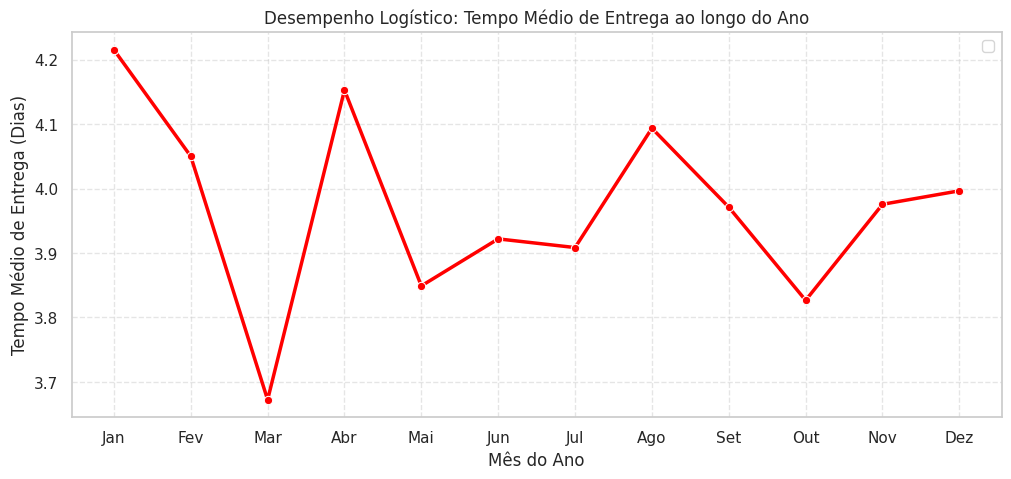

In [32]:
# Agrupando por mês e tirando a MÉDIA do tempo de entrega
tempo_entrega_mensal = df.groupby('Month')['Delivery_Time'].mean().reset_index()

# Gráfico do Tempo de Entrega ao longo do ano
plt.figure(figsize=(12, 5))
sns.lineplot(data=tempo_entrega_mensal, x='Month', y='Delivery_Time', marker='o', color='red', linewidth=2.5)

plt.title('Desempenho Logístico: Tempo Médio de Entrega ao longo do Ano')
plt.xlabel('Mês do Ano')
plt.ylabel('Tempo Médio de Entrega (Dias)')

meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
plt.xticks(range(1, 13), meses_nomes)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Para fechar a nossa análise sobre as entregas e como elas afetam as vendas, chegamos a uma descoberta muito interessante. Ao contrário do que imaginávamos, o sistema de entregas da loja não entra em colapso na época de Black Friday e Natal. Na verdade, os dados mostram que as entregas ficam até mais rápidas em novembro e dezembro, o que indica que a loja se prepara muito bem para esse pico. Isso é fundamental, pois garante que a loja não sofra com reclamações ou cancelamentos em massa justamente na época em que mais vende. Além disso, vimos que a grande maioria dos clientes prefere o frete padrão. Como eles aceitam esperar o tempo normal e não exigem entregas urgentes, a loja economiza muito com transporte, o que ajuda a manter o lucro maior em cada venda. O único ponto de alerta que os gráficos revelaram está no mês de setembro. É nesse mês que as entregas mais demoram. O grande perigo disso é que setembro é o mês de aquecimento, se o cliente compra nessa época e o pedido atrasa, ele tem uma experiência ruim e muito provavelmente desiste de voltar para comprar na Black Friday. Em resumo, a loja acerta muito na logística do final do ano e na economia com fretes, mas precisa focar em resolver esse atraso de setembro para não afastar os clientes bem na véspera da época em que a empresa mais ganha dinheiro.

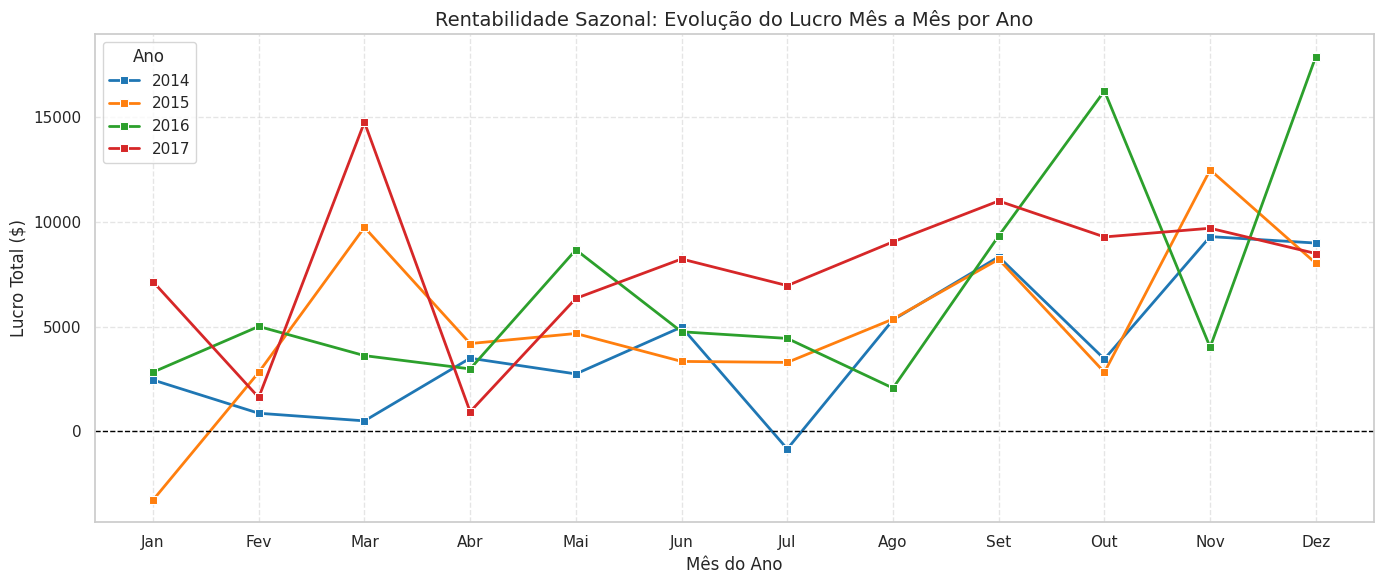

In [33]:
lucro_mensal = df.groupby(['Year', 'Month'])['Profit'].sum().reset_index()

# 3. Plotando o Gráfico de Sazonalidade Mensal do Lucro
plt.figure(figsize=(14, 6))

sns.lineplot(data=lucro_mensal, x='Month', y='Profit', hue='Year', marker='s', palette='tab10', linewidth=2)

plt.title('Rentabilidade Sazonal: Evolução do Lucro Mês a Mês por Ano', fontsize=14)
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Lucro Total ($)', fontsize=12)

# Ajustando o eixo X
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
plt.xticks(range(1, 13), meses_nomes)


# Adicionando uma linha no Zero para mostrar claramente se algum mês deu prejuízo geral
plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Ano')

plt.tight_layout()
plt.show()

In [34]:
# Pegando as 10 vendas com os maiores lucros e mostrando o mês delas
maiores_lucros_mes = df.nlargest(10, 'Profit')[['Order_Date', 'Month', 'Category', 'Profit']]

print("Em quais meses aconteceram os maiores lucros da loja?")
display(maiores_lucros_mes)

# Contando quantos lucros absurdos (acima de 2000 dólares) existem por mês
outliers_por_mes = df[df['Profit'] > 2000].groupby('Month').size().reset_index(name='Qtd_Vendas_Anormais')

Em quais meses aconteceram os maiores lucros da loja?


,Order_Date,Month,Category,Profit
6826,2016-10-02,10,Technology,8399.9760
8153,2017-03-23,3,Technology,6719.9808
4190,2017-11-17,11,Technology,5039.9856
9039,2016-12-17,12,Office Supplies,4946.3700
4098,2014-09-23,9,Office Supplies,4630.4755
2623,2017-10-22,10,Technology,3919.9888
509,2015-03-16,3,Office Supplies,3177.4750
8488,2016-02-02,2,Technology,2799.9840
7666,2016-10-04,10,Technology,2591.9568
6520,2017-01-16,1,Office Supplies,2504.2216


Ao analisarmos a origem dos maiores lucros, confirmamos que a nossa rentabilidade anual está distorcida por um pequeno grupo de vendas excepcionais. Identificamos que meses como outubro e dezembro tiveram seu desempenho financeiro aumentado por poucas transações de valor muito elevado.

Isso significa que o lucro que víamos no gráfico não representa a saúde real do dia a dia da loja, mas sim o sucesso isolado de poucos pedidos. Por outro lado, o mês de novembro, apesar de ser o período de maior movimento, apresenta poucos lucros extremos, reforçando que o volume de vendas dessa época é sustentado por produtos de margem apertada.

In [35]:
df_clean = df.copy()

# Limpando a coluna PROFIT
Q1_profit = df_clean['Profit'].quantile(0.25)
Q3_profit = df_clean['Profit'].quantile(0.75)
IQR_profit = Q3_profit - Q1_profit

limite_inf_profit = Q1_profit - 1.5 * IQR_profit
limite_sup_profit = Q3_profit + 1.5 * IQR_profit

# Aqui deixamos o limite inferior ser negativo normalmente
df_clean = df_clean[(df_clean['Profit'] >= limite_inf_profit) & (df_clean['Profit'] <= limite_sup_profit)]


# Limpando a coluna SALES (Vendas)
Q1_sales = df_clean['Sales'].quantile(0.25)
Q3_sales = df_clean['Sales'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales

# Aqui usamos o max(0, ...) para garantir que o limite de vendas não caia abaixo de zero
limite_inf_sales = max(0, Q1_sales - 1.5 * IQR_sales)
limite_sup_sales = Q3_sales + 1.5 * IQR_sales

df_clean = df_clean[(df_clean['Sales'] >= limite_inf_sales) & (df_clean['Sales'] <= limite_sup_sales)]

print(f'O dataset original possui {df.shape[0]} amostras')
print(f'O dataset limpo agora possui {df_clean.shape[0]} amostras')
print(f'Foram removidas {df.shape[0] - df_clean.shape[0]} linhas que eram pontos fora da curva (outliers).')

O dataset original possui 9994 amostras
O dataset limpo agora possui 7296 amostras
Foram removidas 2698 linhas que eram pontos fora da curva (outliers).


In [36]:
df_clean.describe()

,Row_ID,Order_Date,Ship_Date,Postal_Code,Sales,Quantity,Discount,Profit,Year,Quarter,Month,Delivery_Time
count,7296.000000,7296,7296,7296.000000,7296.000000,7296.000000,7296.000000,7296.000000,7296.000000,7296.000000,7296.000000,7296.000000
mean,5001.304550,2016-05-02 07:57:14.210526464,2016-05-06 07:13:48.947368448,55249.269874,50.440108,3.486157,0.148505,10.202259,2015.730674,2.875137,7.787829,3.969846
min,3.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1453.000000,0.444000,1.000000,0.000000,-39.637000,2014.000000,1.000000,1.000000,0.000000
25%,2500.750000,2015-05-26 00:00:00,2015-05-29 00:00:00,23223.000000,12.840000,2.000000,0.000000,2.035350,2015.000000,2.000000,5.000000,3.000000
50%,4999.500000,2016-07-02 00:00:00,2016-07-03 00:00:00,55901.000000,29.770000,3.000000,0.000000,6.684600,2016.000000,3.000000,9.000000,4.000000
75%,7490.250000,2017-05-15 00:00:00,2017-05-20 00:00:00,90008.000000,71.096000,5.000000,0.200000,16.006950,2017.000000,4.000000,11.000000,5.000000
max,9993.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,227.976000,14.000000,0.800000,70.722000,2017.000000,4.000000,12.000000,7.000000
std,2886.204687,NaN,NaN,32088.488805,52.077875,2.061249,0.205464,16.605861,1.122624,1.057449,3.285408,1.746331


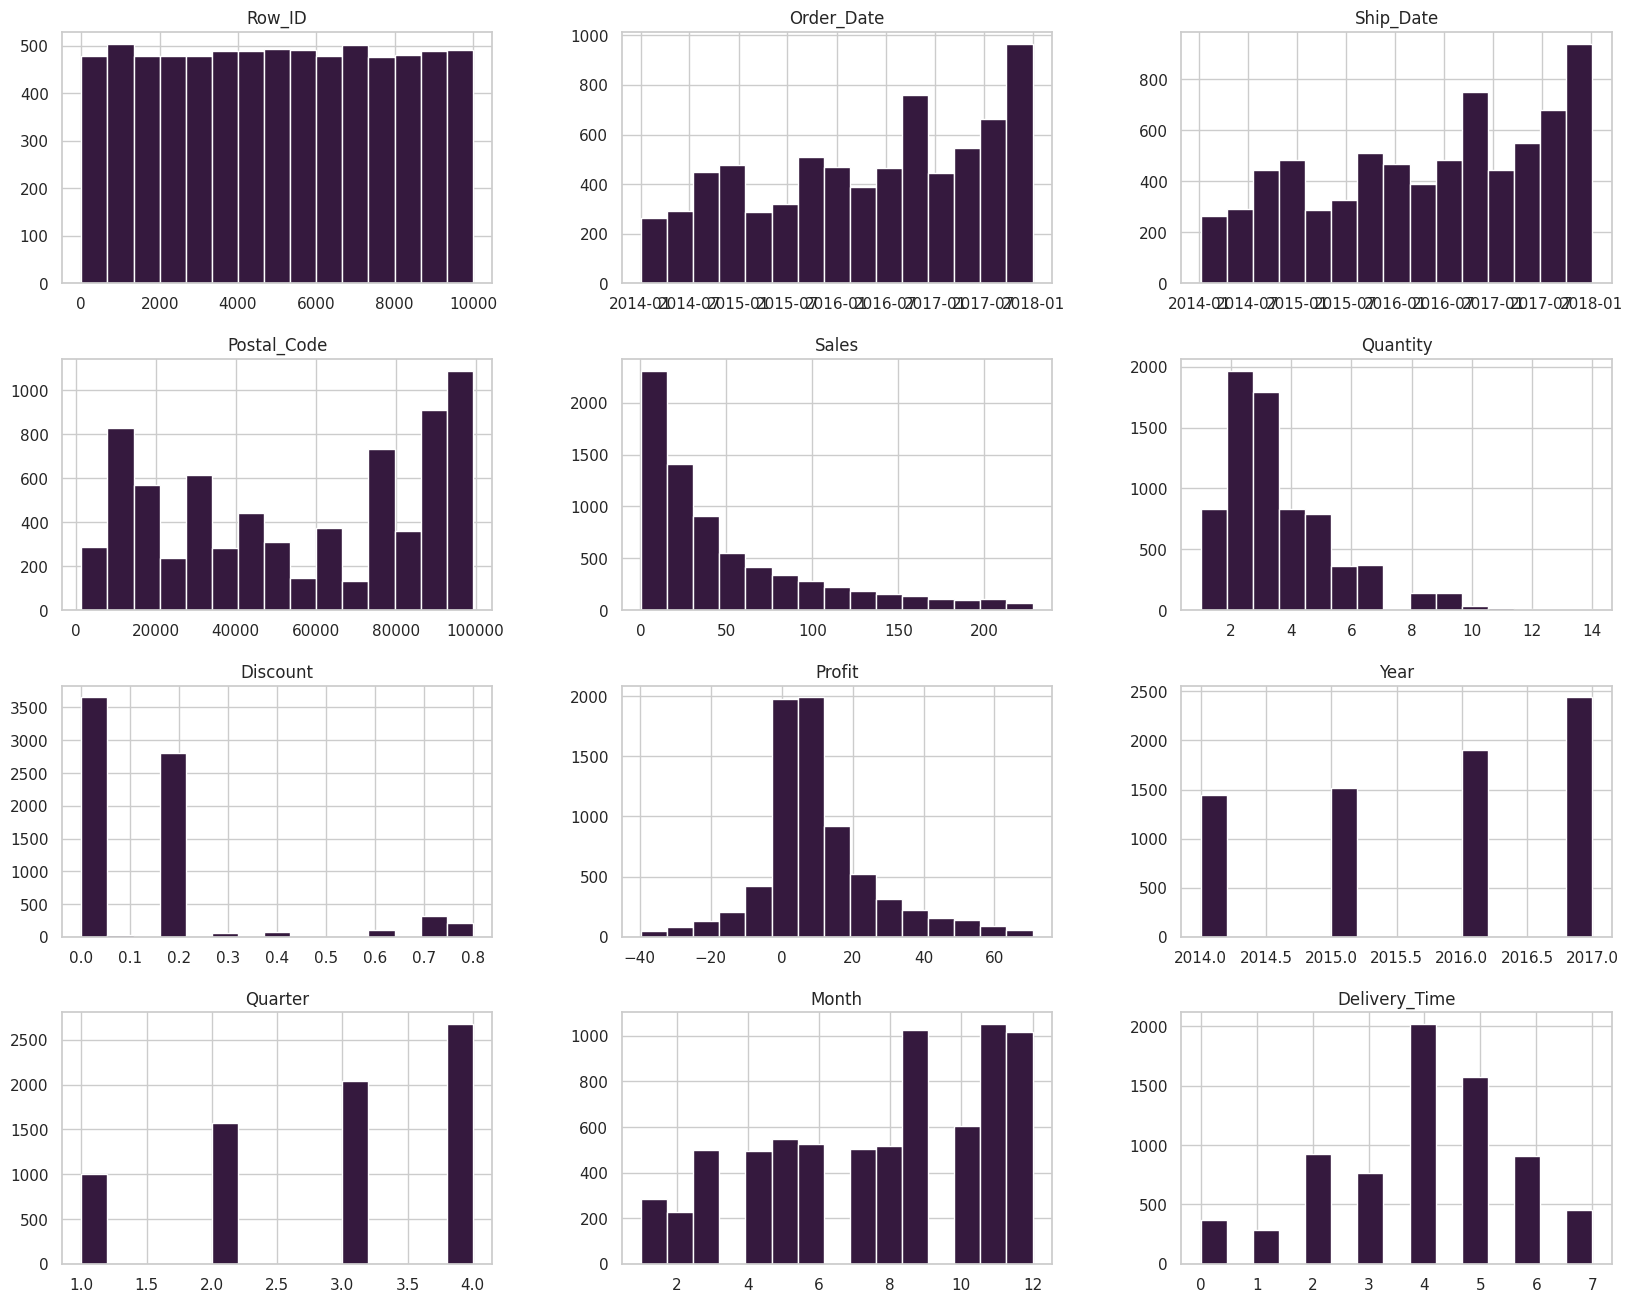

In [37]:
df_clean.hist(bins=15, figsize=(20,16));

/tmp/ipykernel_9256/4164496416.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lucro_cat_sujo, x='Category', y='Profit', palette='Reds_r', ax=axes[0])
/tmp/ipykernel_9256/4164496416.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lucro_cat_limpo, x='Category', y='Profit', palette='viridis', ax=axes[1])


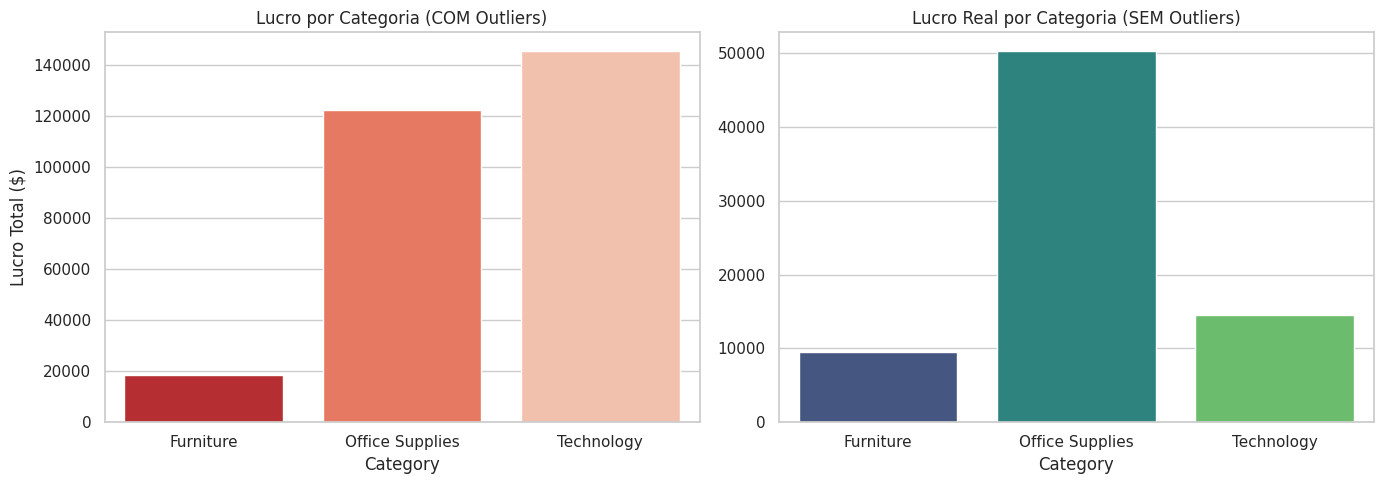

In [38]:
# Agrupando os dados
lucro_cat_sujo = df.groupby('Category')['Profit'].sum().reset_index()
lucro_cat_limpo = df_clean.groupby('Category')['Profit'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico da base Suja
sns.barplot(data=lucro_cat_sujo, x='Category', y='Profit', palette='Reds_r', ax=axes[0])
axes[0].set_title('Lucro por Categoria (COM Outliers)')
axes[0].set_ylabel('Lucro Total ($)')

# Gráfico da base Limpa
sns.barplot(data=lucro_cat_limpo, x='Category', y='Profit', palette='viridis', ax=axes[1])
axes[1].set_title('Lucro Real por Categoria (SEM Outliers)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Essa limpeza dos dados prova que o supermercado não sobrevive de vendas que dão milhares de dólares de lucro de uma só vez. A verdadeira força e a saúde financeira da empresa vêm das vendas constantes com giro rapido.

A loja depende inteiramente do giro rápido, ou seja, precisa vender uma quantidade enorme de produtos todos os dias. Como a margem de lucro natural da loja já é muito pequena e frágil na sua rotina normal, qualquer política de descontos agressivos tem a possibilidade de transformar o esforço de vendas em prejuízo.

/tmp/ipykernel_9256/867044025.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lucro_seg_sujo, x='Segment', y='Profit', palette='Reds_r', ax=axes[0])
/tmp/ipykernel_9256/867044025.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lucro_seg_limpo, x='Segment', y='Profit', palette='viridis', ax=axes[1])


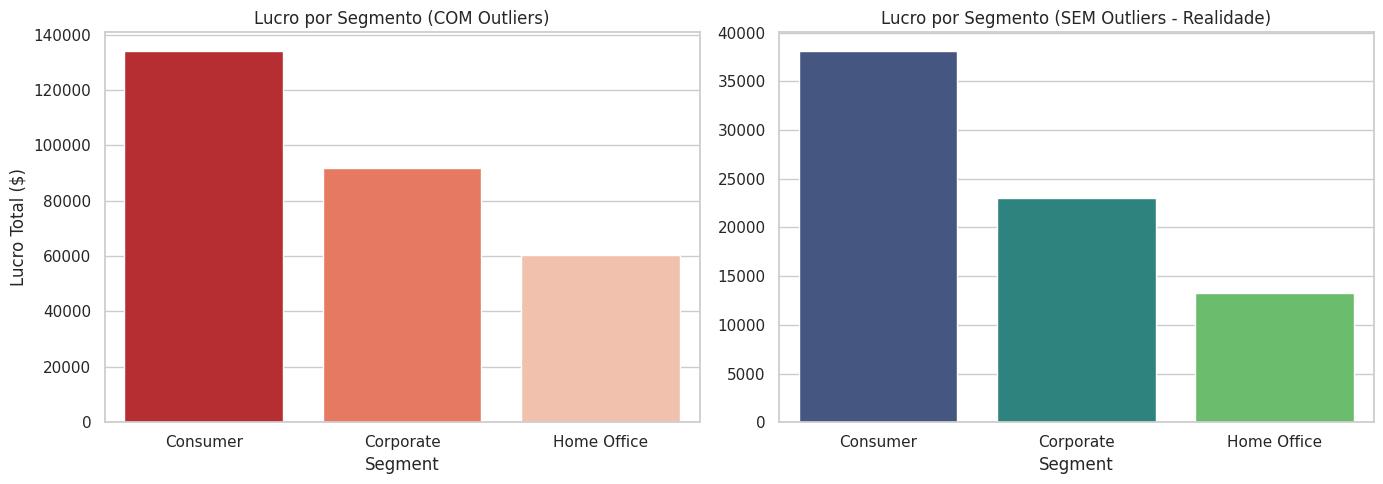

In [39]:
# Agrupando os dados por Segmento
lucro_seg_sujo = df.groupby('Segment')['Profit'].sum().reset_index()
lucro_seg_limpo = df_clean.groupby('Segment')['Profit'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Sujo (Com Outliers)
sns.barplot(data=lucro_seg_sujo, x='Segment', y='Profit', palette='Reds_r', ax=axes[0])
axes[0].set_title('Lucro por Segmento (COM Outliers)')
axes[0].set_ylabel('Lucro Total ($)')

# Gráfico Limpo (Sem Outliers)
sns.barplot(data=lucro_seg_limpo, x='Segment', y='Profit', palette='viridis', ax=axes[1])
axes[1].set_title('Lucro por Segmento (SEM Outliers - Realidade)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_9256/380932645.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lucro_cat_sujo, x='Category', y='Profit', palette='Reds_r', ax=axes[0])
/tmp/ipykernel_9256/380932645.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lucro_cat_limpo, x='Category', y='Profit', palette='viridis', ax=axes[1])


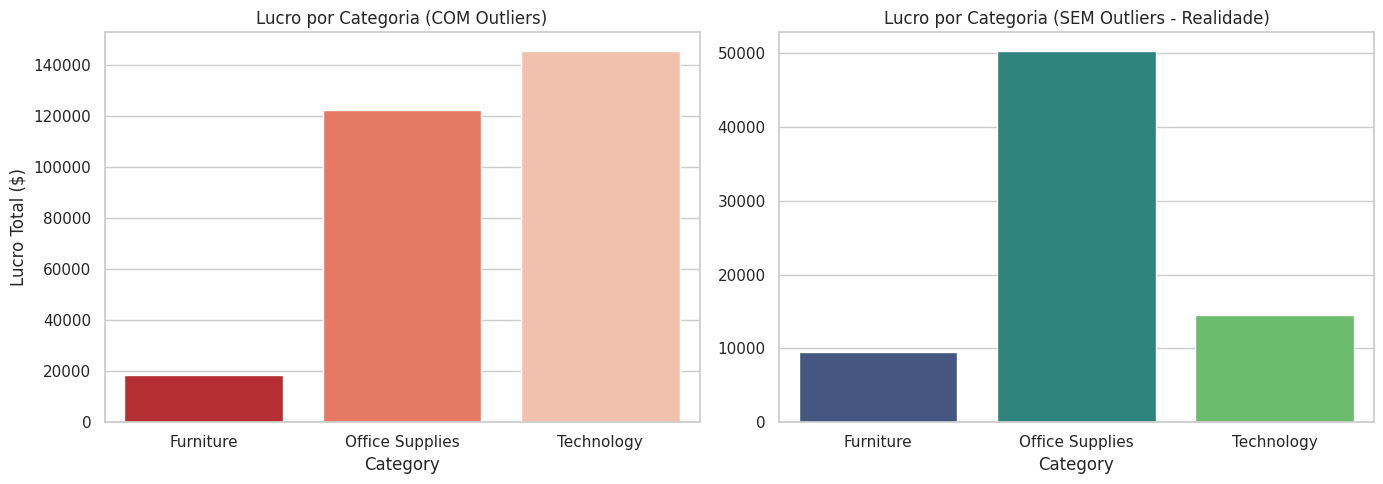

In [40]:
# Agrupando os dados por Categoria
lucro_cat_sujo = df.groupby('Category')['Profit'].sum().reset_index()
lucro_cat_limpo = df_clean.groupby('Category')['Profit'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Sujo
sns.barplot(data=lucro_cat_sujo, x='Category', y='Profit', palette='Reds_r', ax=axes[0])
axes[0].set_title('Lucro por Categoria (COM Outliers)')
axes[0].set_ylabel('Lucro Total ($)')

# Gráfico Limpo
sns.barplot(data=lucro_cat_limpo, x='Category', y='Profit', palette='viridis', ax=axes[1])
axes[1].set_title('Lucro por Categoria (SEM Outliers - Realidade)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Ao compararmos a nossa visão inicial com a realidade da loja, a conclusão é bem direta: achávamos que a empresa se sustentava vendendo produtos caros de tecnologia, mas, na verdade, o que mais traz lucro constante para o caixa são os itens básicos e baratos do dia a dia, como materiais de escritório.

Isso afeta totalmente a estratégia do negócio. Como a loja ganha apenas alguns poucos dólares em cada produto, ela depende de vender um volume gigantesco todos os dias para conseguir fechar o mês no azul, e não de uma ou duas vendas milagrosas de produtos caros.

##Análise Regiões com Baixa Rentabilidade

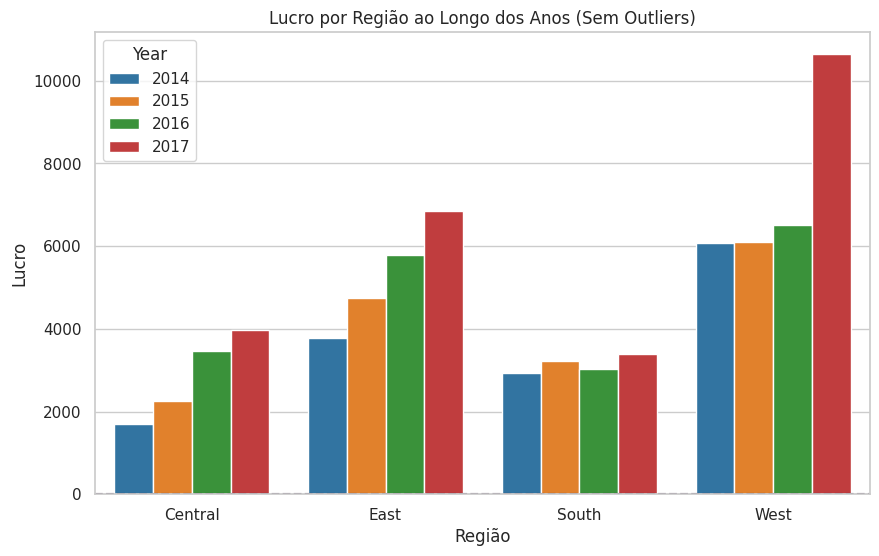

In [41]:
#. Agrupando dados para visualização em gráfico
dados_rendimento_regiao = df_clean.groupby(['Year', 'Region'])['Profit'].sum().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(data=dados_rendimento_regiao, x='Region', y='Profit', hue='Year', palette='tab10')

plt.title('Lucro por Região ao Longo dos Anos (Sem Outliers)')
plt.xlabel('Região')
plt.ylabel('Lucro')

plt.axhline(0, linestyle='--')

plt.show()

- Podemos ver que as regiões Central e South, são as piores regiões em todos os anos.

###Análisando as regiões Central (Pior) e South (Segunda Pior) de 2014

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


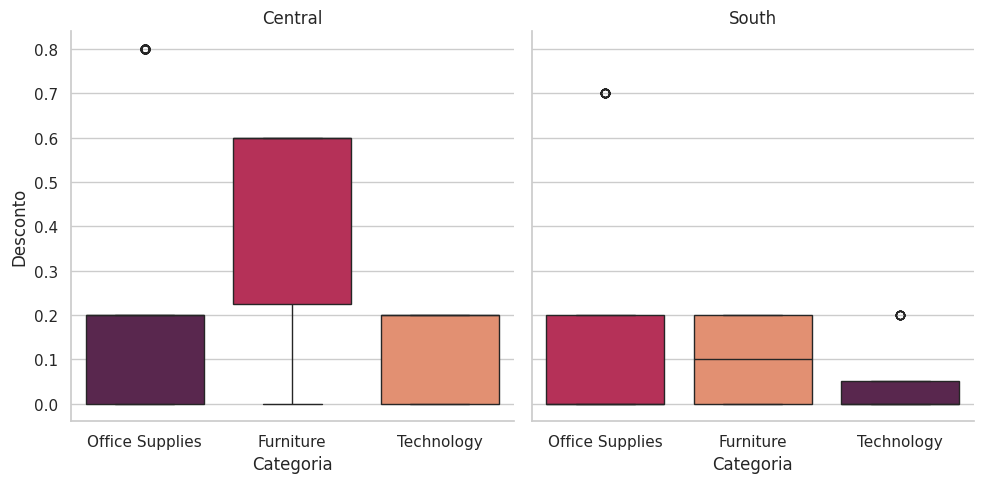

In [45]:
dados = df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'].isin(['Central', 'South']))]

g = sns.FacetGrid(dados, col='Region', height=5, sharey=True)

g.map_dataframe(sns.boxplot, x='Category', y='Discount', palette='rocket')

g.set_titles(col_template='{col_name}')
g.set_axis_labels('Categoria', 'Desconto')

plt.show()

- Aqui podemos observar que o prejuízo de uma região se dá pela relação desconto x categoria. A região central foi pior por dar mais desconto em Furniture, que por mais que não tenha um valor agragado tão alto, recebendo um desconto grande prejudica ainda mais. Já a região South "preservou" uma categoria que é mais lucrativa, Technology, de descontos altos o que garente uma rentabiilidade maior

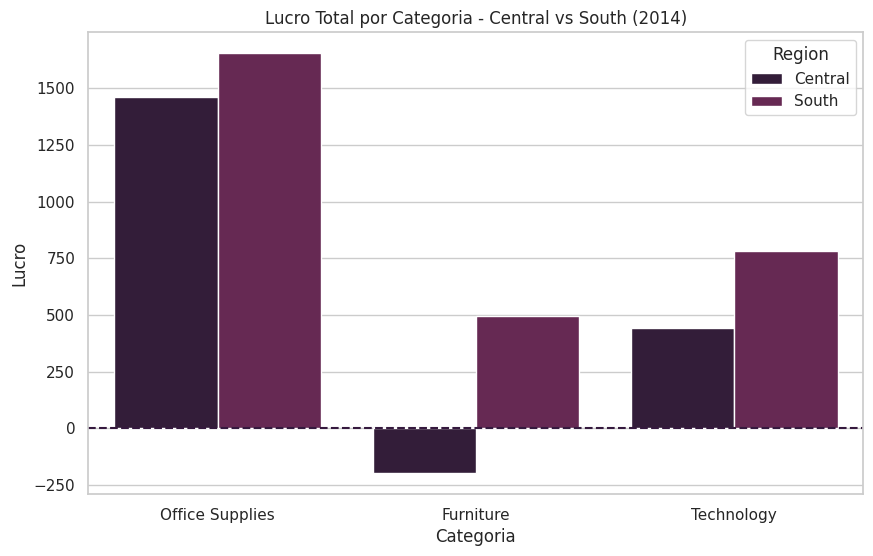

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'].isin(['Central', 'South']))], x='Category', y='Profit', hue='Region', estimator=sum, errorbar=None)

plt.axhline(0, linestyle='--')

plt.title('Lucro Total por Categoria - Central vs South (2014)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.show()

###Análise Regiões Central (Pior) e South (Segunda Pior) de 2015

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


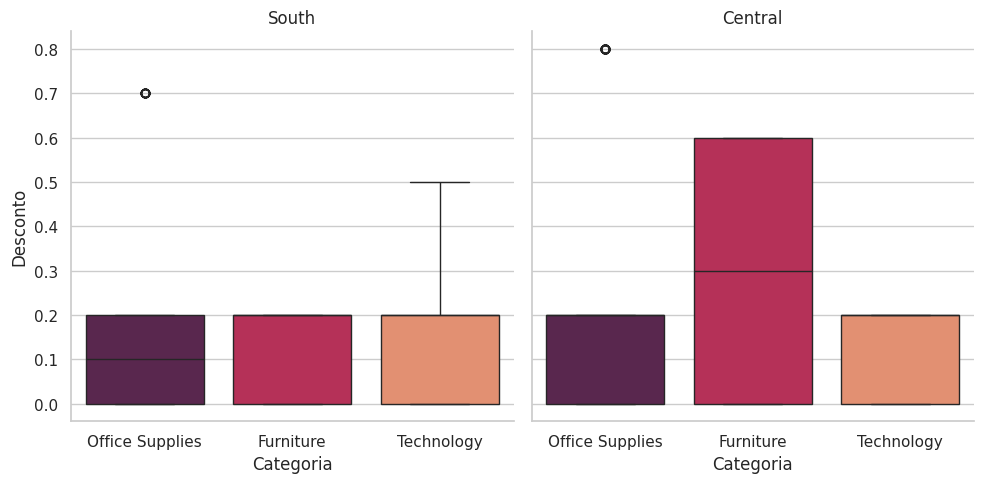

In [48]:
dados = df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'].isin(['Central', 'South']))]

g = sns.FacetGrid(dados, col='Region', height=5, sharey=True)

g.map_dataframe(sns.boxplot, x='Category', y='Discount', palette='rocket')

g.set_titles(col_template='{col_name}')
g.set_axis_labels('Categoria', 'Desconto')

plt.show()

- Aqui podemos ver algo similar ao ano passado, região central deu muito desconto em Furniture e mais desconto para a categoria de Office Supplies do que a região South deu. Sendo assim, essa agregação de descontos tanto para uma categoria rentável quanto para uma não tão rentável acumulou em Prejuízo.

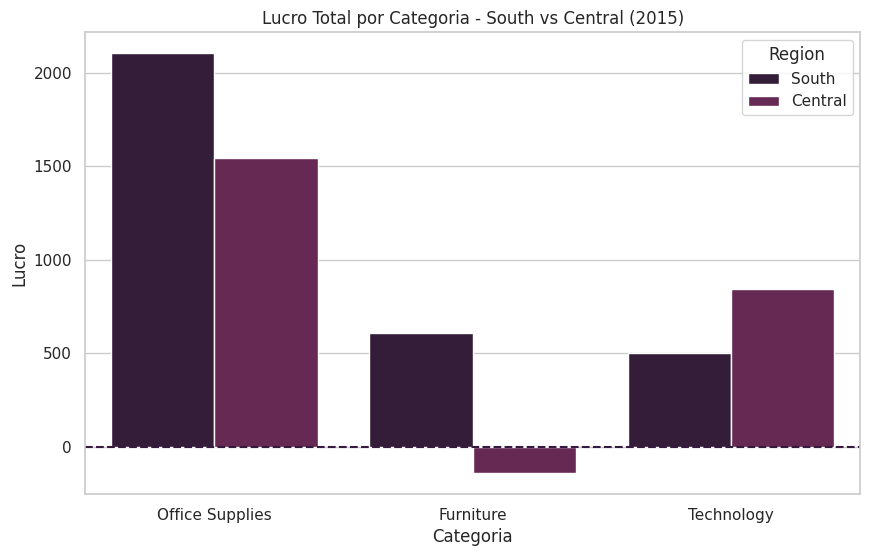

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'].isin(['Central', 'South']))], x='Category', y='Profit', hue='Region', estimator=sum, errorbar=None)

plt.axhline(0, linestyle='--')

plt.title('Lucro Total por Categoria - South vs Central (2015)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.show()

###Análise South (Pior) e Central (Segunda Pior) de 2016

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


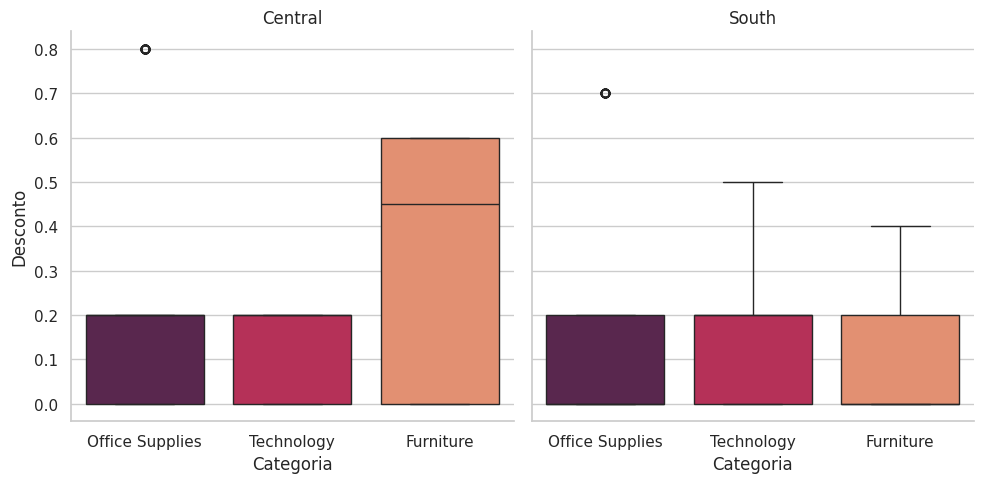

In [50]:
dados = df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'].isin(['Central', 'South']))]

g = sns.FacetGrid(dados, col='Region', height=5, sharey=True)

g.map_dataframe(sns.boxplot, x='Category', y='Discount', palette='rocket')

g.set_titles(col_template='{col_name}')
g.set_axis_labels('Categoria', 'Desconto')

plt.show()

- Aqui podemos ver o quão é perigoso distribuir descontos altos em categorias com alto valor agragado. As duas regiões se parecem muito em relação a distribuição de descontos. Porém, a região central distribuiu muito desconto em Furniture. Mas, a região South distribuiu muito desconto em Technology, uma categoria de alto valor agragado, assim gerando um grande impacto em sua rentabilidade.

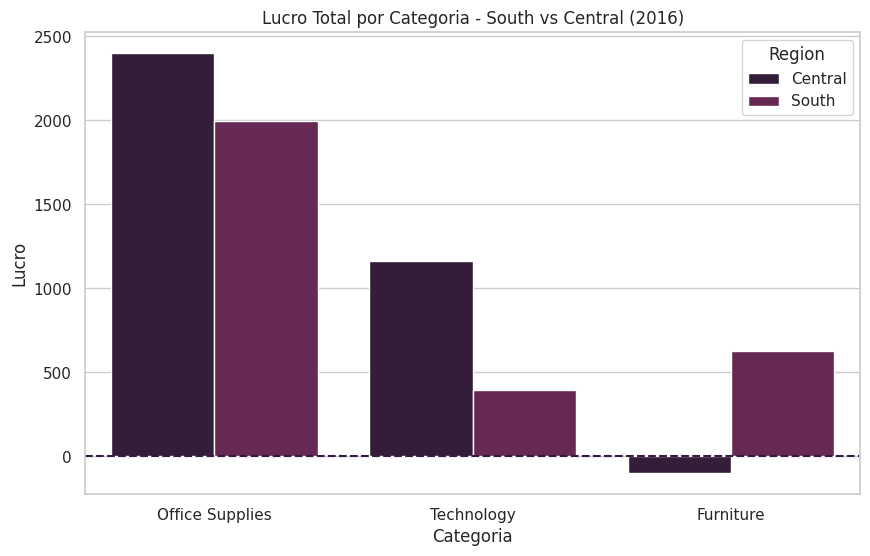

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'].isin(['South', 'Central']))], x='Category', y='Profit', hue='Region', estimator=sum, errorbar=None)

plt.axhline(0, linestyle='--')

plt.title('Lucro Total por Categoria - South vs Central (2016)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.show()

###Análise South (Pior) e Central (Segunda Pior) de 2017

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


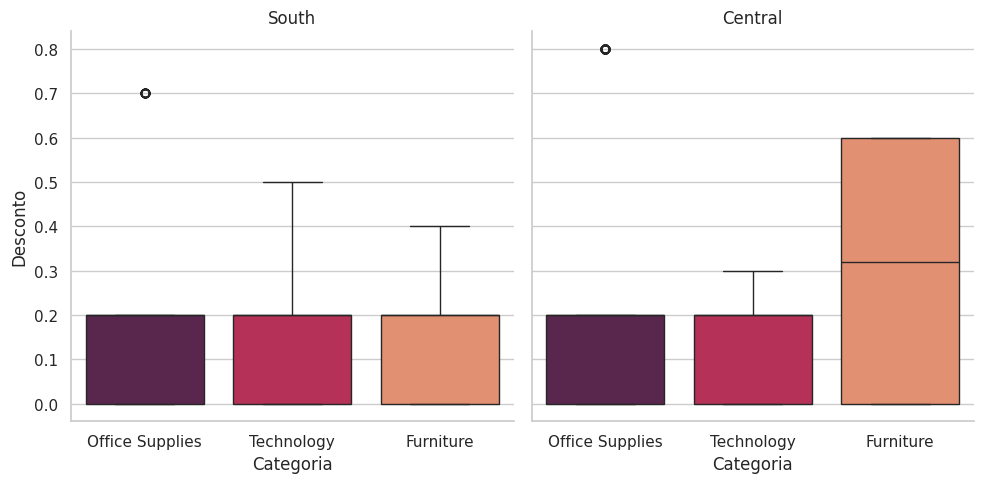

In [52]:
dados = df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'].isin(['Central', 'South']))]

g = sns.FacetGrid(dados, col='Region', height=5, sharey=True)

g.map_dataframe(sns.boxplot, x='Category', y='Discount', palette='rocket')

g.set_titles(col_template='{col_name}')
g.set_axis_labels('Categoria', 'Desconto')

plt.show()

- Aqui podemos ver o mesmo comportamento, a região South deu mais desconto para uma categoria de alto valor agregado enquanto a região Central deu mais desconto para uma categoria de pouco valor agregado, gera prejuízo, mas não no mesmo nível de uma categoria de alto valor.

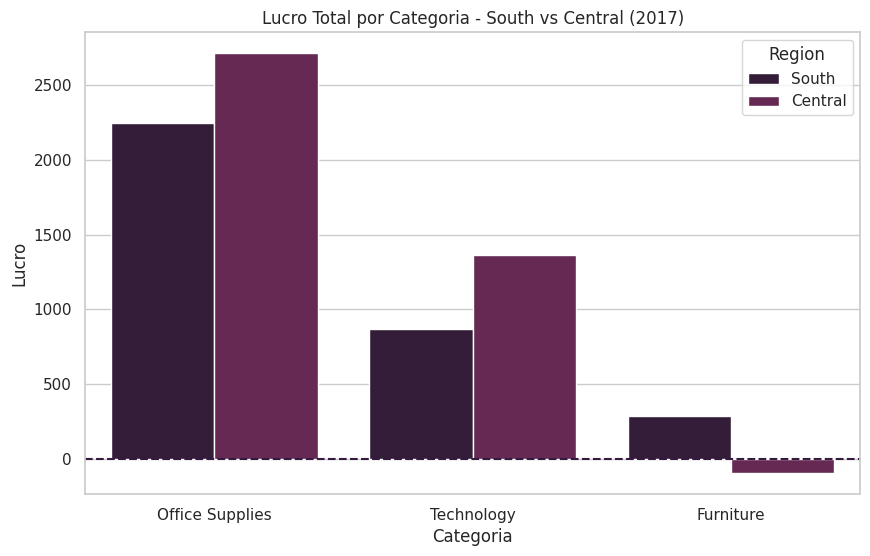

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'].isin(['South', 'Central']))], x='Category', y='Profit', hue='Region', estimator=sum, errorbar=None)

plt.axhline(0, linestyle='--')

plt.title('Lucro Total por Categoria - South vs Central (2017)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.show()

##Análise Clientes com Baixa Rentabilidade

###Top 10 Piores Clientes de 2014

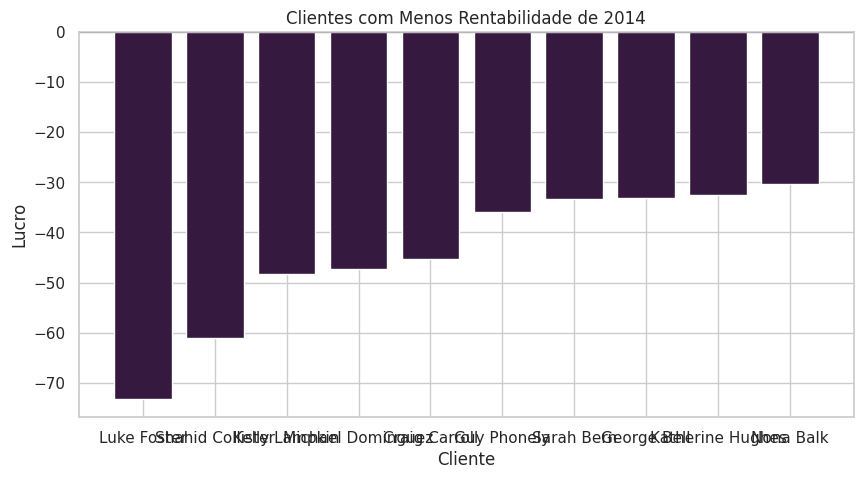

In [55]:
rentabilidade_clientes = df_clean[df_clean['Year'] == 2014].groupby('Customer_Name')['Profit'].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(10,5))

plt.bar(rentabilidade_clientes.index, rentabilidade_clientes.values)

plt.title('Clientes com Menos Rentabilidade de 2014')
plt.xlabel('Cliente')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

- Podemos observar que Luke Foster foi o cliente que mais deu prejuízo nesse ano, com uma certa vantagem do segundo colocado.

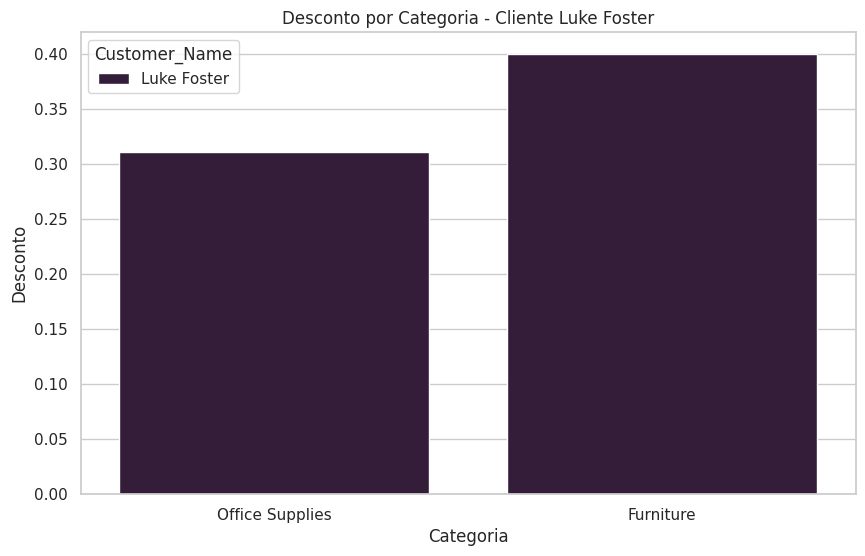

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[df_clean['Customer_Name'] == 'Luke Foster'], x='Category', y='Discount', hue='Customer_Name', estimator='mean', errorbar=None)

plt.title('Desconto por Categoria - Cliente Luke Foster')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

- Similar ao que vimos na Análise de Regiões, Ao recber descontos "altos" em categorias muito rentáveis, como Office Supplies, o resultado é prejuízo para a empresa.

###Top 10 Piores Clientes de 2015

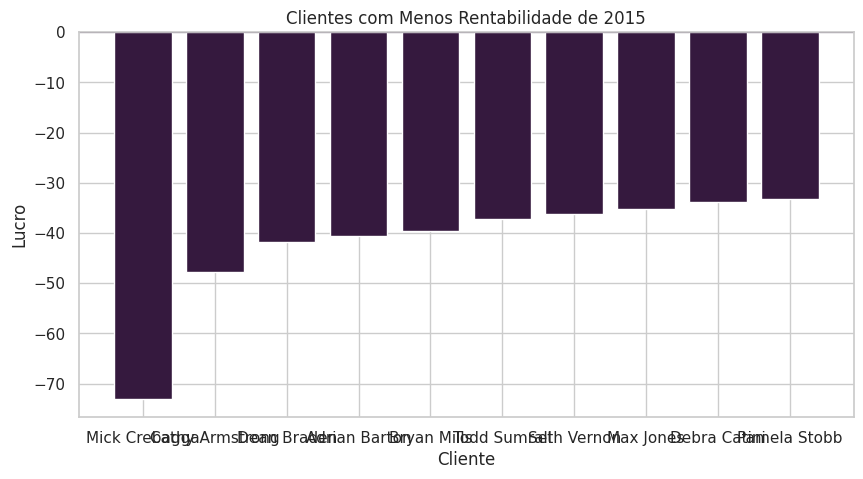

In [58]:
rentabilidade_clientes_2015 = df_clean[df_clean['Year'] == 2015].groupby('Customer_Name')['Profit'].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(10,5))

plt.bar(rentabilidade_clientes_2015.index, rentabilidade_clientes_2015.values)

plt.title('Clientes com Menos Rentabilidade de 2015')
plt.xlabel('Cliente')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

- Novamente, precisamos verificar qual foi o motivo do baixo rendimento desses clientes. Como vimos anteriormente, o tamanho do desconto pode ser o principal motivo do prejuízo causado, mesmo se tratando de categorias rentáveis.

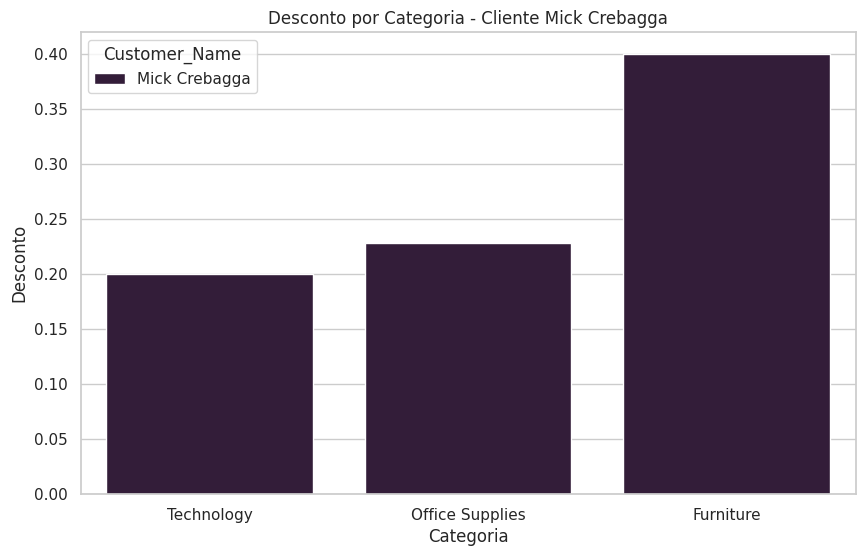

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[df_clean['Customer_Name'] == 'Mick Crebagga'], x='Category', y='Discount', hue='Customer_Name', estimator='mean', errorbar=None)

plt.title('Desconto por Categoria - Cliente Mick Crebagga')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

- Realmente, descontos altos tendem a gerar prejuízo para empresa, até mesmo quando esses descontos são aplicados a categorias que não tem tanto valor, como Furniture, já que o retorno que era pouco se torna quase mínimo ou nulo e até mesmo negativo.

###Top 10 Piores Clientes de 2016

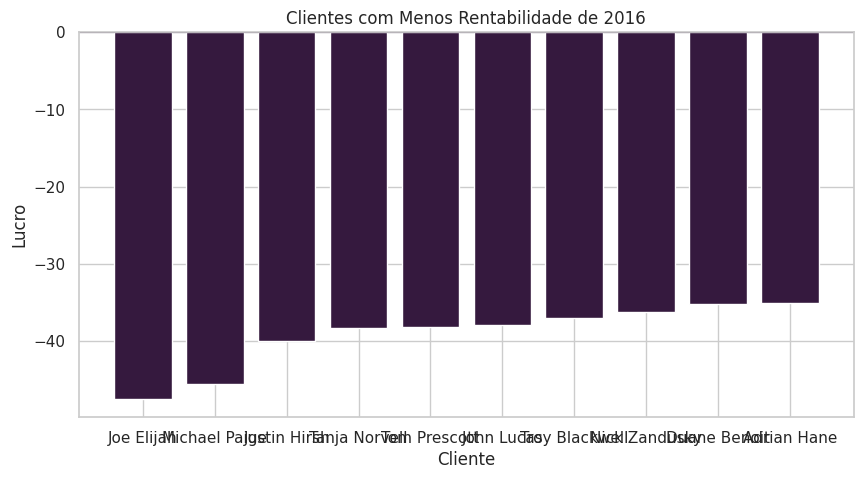

In [60]:
rentabilidade_clientes_2016 = df_clean[df_clean['Year'] == 2016].groupby('Customer_Name')['Profit'].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(10,5))

plt.bar(rentabilidade_clientes_2016.index, rentabilidade_clientes_2016.values)

plt.title('Clientes com Menos Rentabilidade de 2016')
plt.xlabel('Cliente')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

- Aqui podemos ver que o pior cliente foi Joe Elijah, bem próximo do segundo colocado

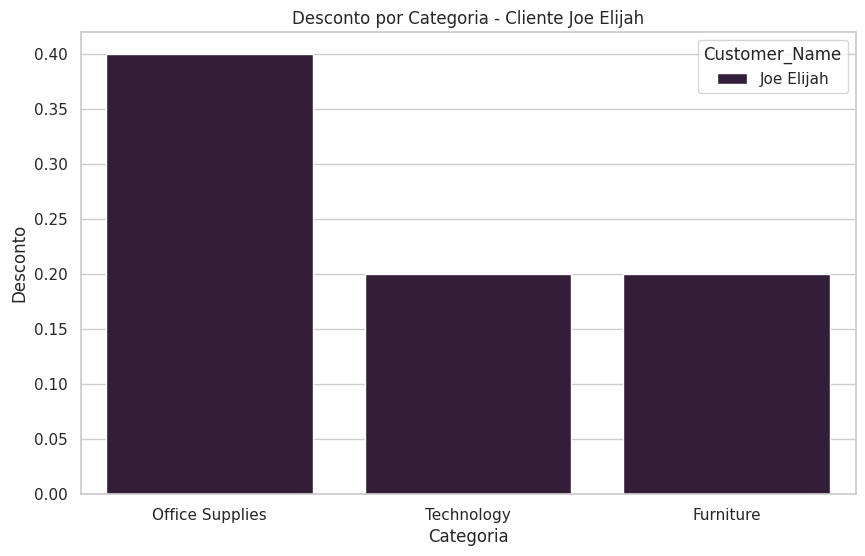

In [61]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[df_clean['Customer_Name'] == 'Joe Elijah'], x='Category', y='Discount', hue='Customer_Name', estimator='mean', errorbar=None)

plt.title('Desconto por Categoria - Cliente Joe Elijah')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

- Aqui já é algo muito mais visível, o cliente recebeu descontos altos em uma categoria rentável, Office Supplies, assim o prejuízo além de mais certo também tende a ser maior.

###Análise 10 Piores Clientes 2017

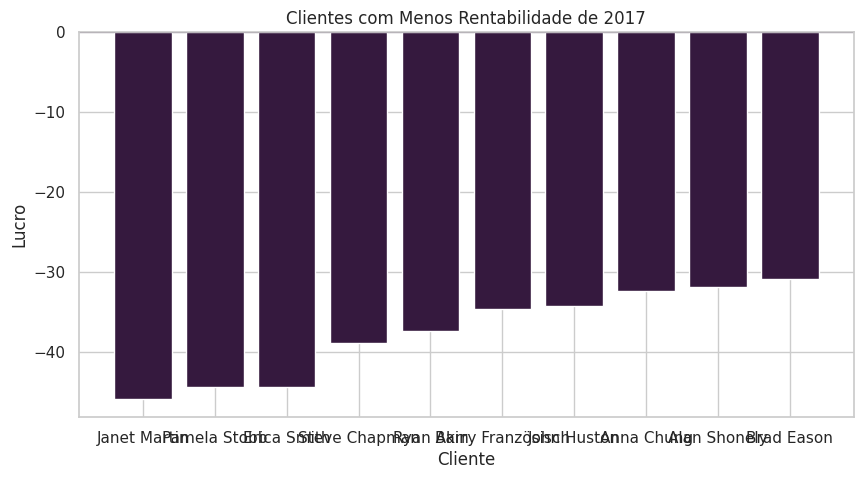

In [62]:
rentabilidade_clientes_2017 = df_clean[df_clean['Year'] == 2017].groupby('Customer_Name')['Profit'].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(10,5))

plt.bar(rentabilidade_clientes_2017.index, rentabilidade_clientes_2017.values)

plt.title('Clientes com Menos Rentabilidade de 2017')
plt.xlabel('Cliente')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

- Nesse ano, o pior cliente foi Janet Martin

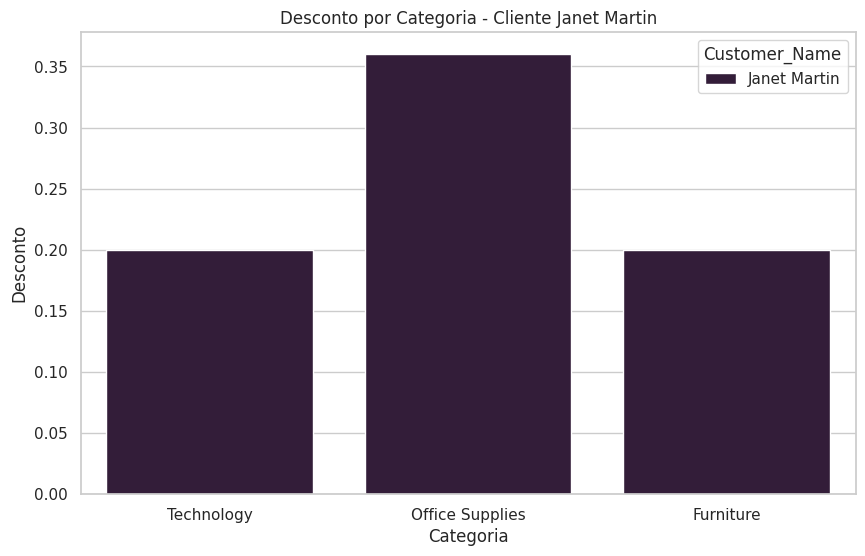

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[df_clean['Customer_Name'] == 'Janet Martin'], x='Category', y='Discount', hue='Customer_Name', estimator='mean', errorbar=None)

plt.title('Desconto por Categoria - Cliente Janet Martin')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

- Esse caso é muito similar ao que vimos anteriormente, alto desconto em uma categoria rentável resulta em prejuízo para empresa.

##Análise Sazonalidade

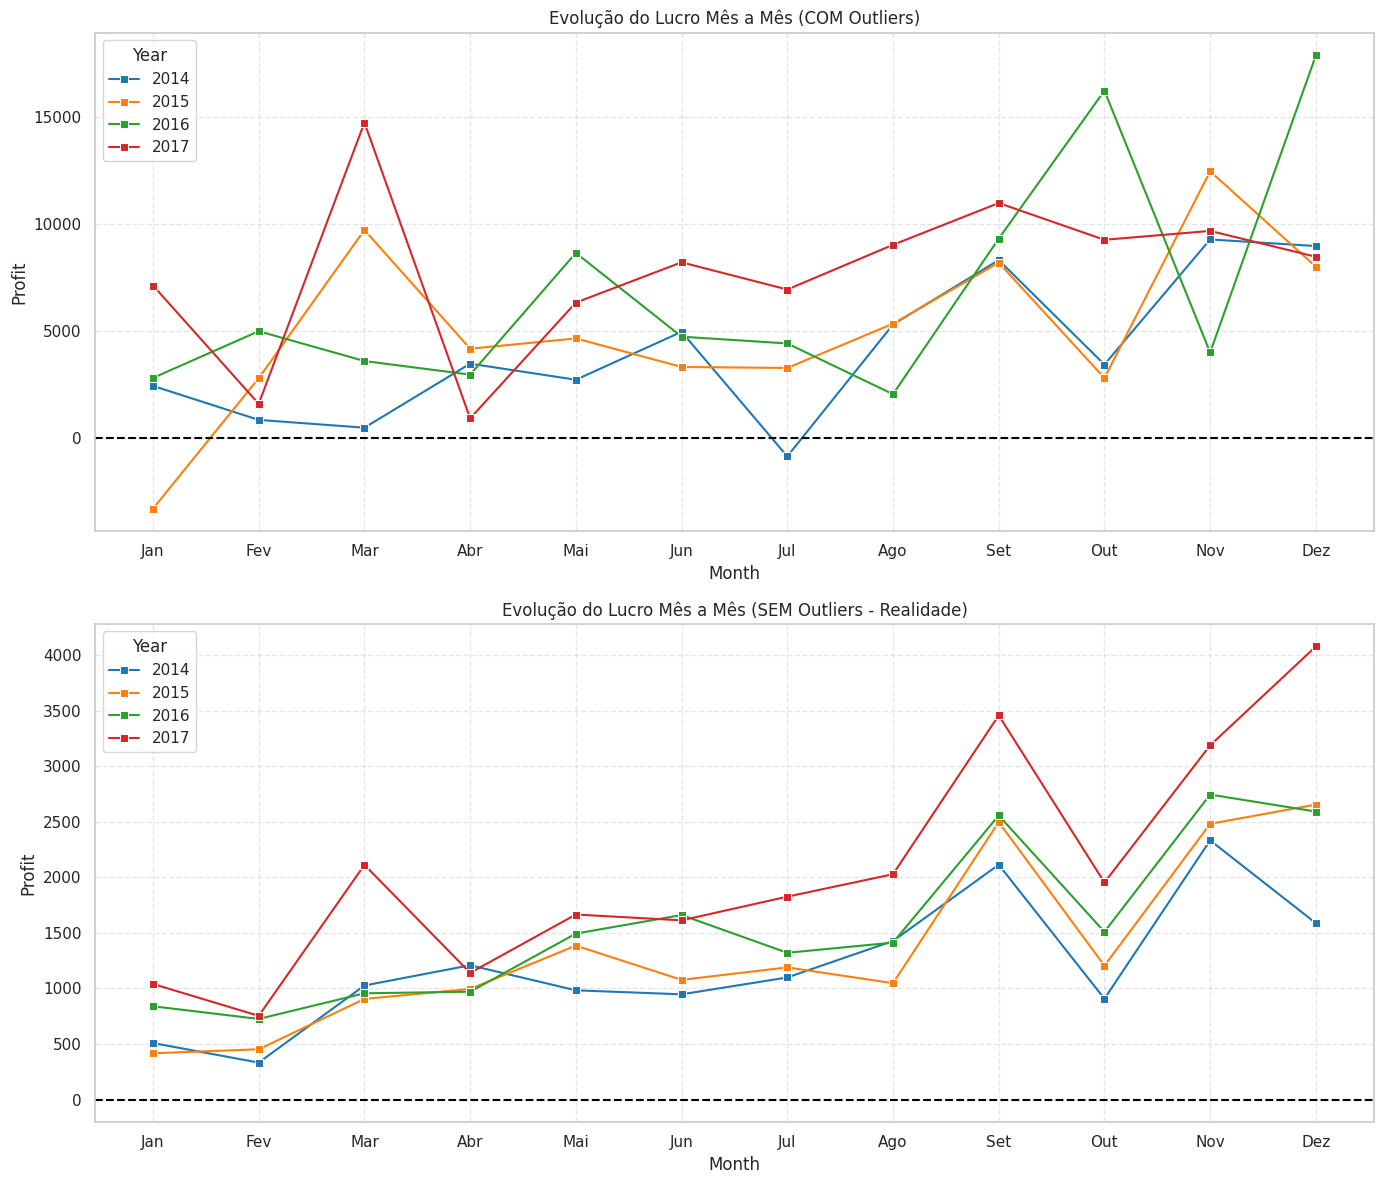

In [42]:
# Garantindo o formato de data (caso alguma coluna tenha se perdido)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year

df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'])
df_clean['Month'] = df_clean['Order_Date'].dt.month
df_clean['Year'] = df_clean['Order_Date'].dt.year

# Agrupando lucro por mês
lucro_mes_sujo = df.groupby(['Year', 'Month'])['Profit'].sum().reset_index()
lucro_mes_limpo = df_clean.groupby(['Year', 'Month'])['Profit'].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

# Gráfico Sujo (Em cima)
sns.lineplot(data=lucro_mes_sujo, x='Month', y='Profit', hue='Year', marker='s', palette='tab10', ax=axes[0])
axes[0].set_title('Evolução do Lucro Mês a Mês (COM Outliers)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses_nomes)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico Limpo (Embaixo)
sns.lineplot(data=lucro_mes_limpo, x='Month', y='Profit', hue='Year', marker='s', palette='tab10', ax=axes[1])
axes[1].set_title('Evolução do Lucro Mês a Mês (SEM Outliers - Realidade)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses_nomes)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Ao compararmos o gráfico antigo com o novo, percebemos que a loja constrói o seu lucro ao longo do ano de forma muito mais constante e saudável do que pensávamos, e não dependendo de grandes vendas em meses específicos.

No gráfico antigo, tínhamos a ilusão de que a loja operava como uma montanha-russa, com picos grandes de lucro em meses como outubro e dezembro.

Já no gráfico limpo, que mostra a rotina de verdade, vemos que o lucro acompanha as vendas de um jeito muito mais lógico e previsível. O fim do ano (novembro e dezembro) continua sendo de fato, a época mais lucrativa para a empresa. A diferença é que agora vemos que esse ganho é real é construído pelo volume enorme de clientes comprando produtos normais do dia a dia, e não por uma venda fora da curva.

/tmp/ipykernel_9256/1375100238.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Profit', y='Segment', palette='Set2', ax=axes[0])
/tmp/ipykernel_9256/1375100238.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Profit', y='Segment', palette='Set2', ax=axes[1])


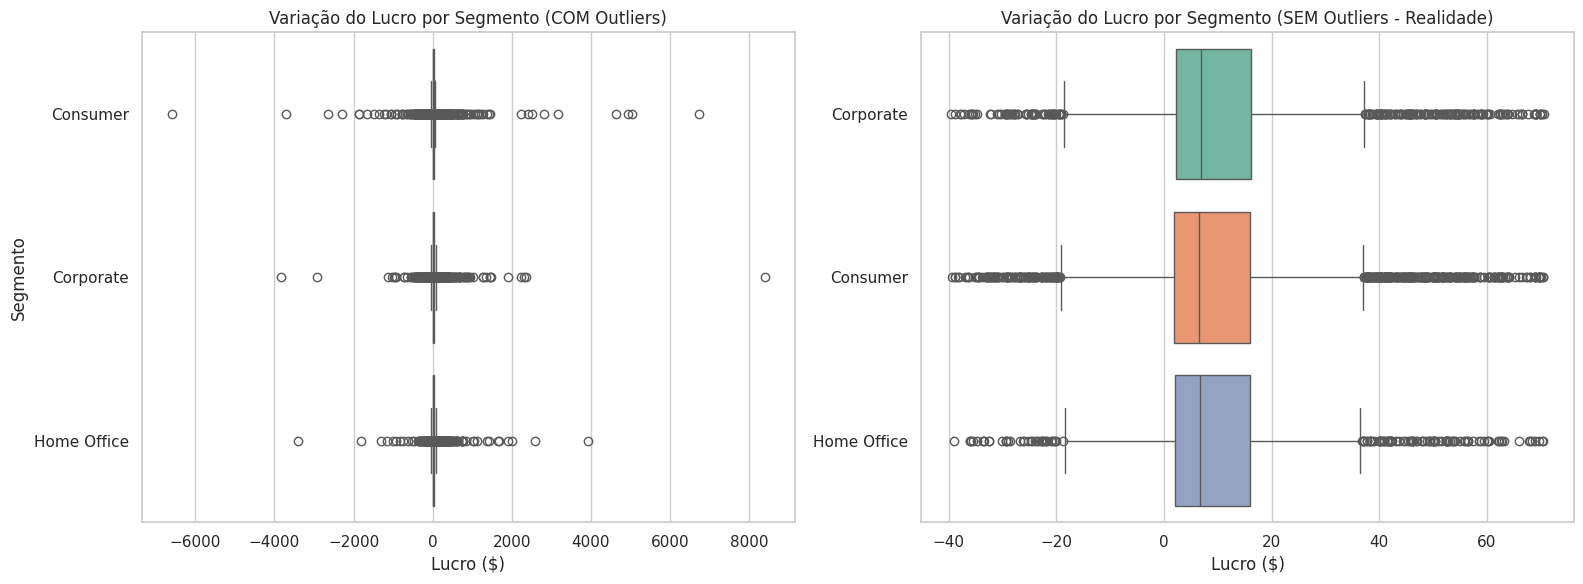

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Sujo (Com Outliers)
sns.boxplot(data=df, x='Profit', y='Segment', palette='Set2', ax=axes[0])
axes[0].set_title('Variação do Lucro por Segmento (COM Outliers)')
axes[0].set_xlabel('Lucro ($)')
axes[0].set_ylabel('Segmento')

# Boxplot Limpo (Sem Outliers)
sns.boxplot(data=df_clean, x='Profit', y='Segment', palette='Set2', ax=axes[1])
axes[1].set_title('Variação do Lucro por Segmento (SEM Outliers - Realidade)')
axes[1].set_xlabel('Lucro ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_9256/915099022.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Profit', y='Category', palette='Set3', ax=axes[0])
/tmp/ipykernel_9256/915099022.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Profit', y='Category', palette='Set3', ax=axes[1])


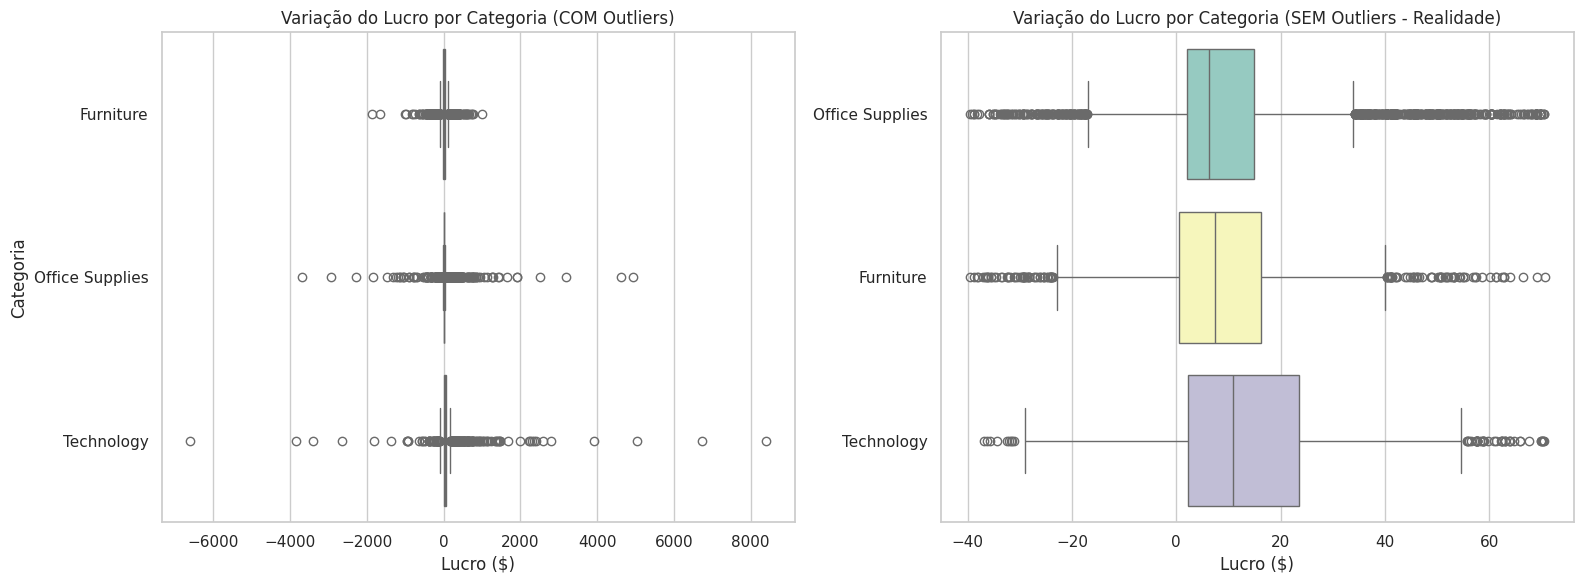

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Sujo (Com Outliers)
sns.boxplot(data=df, x='Profit', y='Category', palette='Set3', ax=axes[0])
axes[0].set_title('Variação do Lucro por Categoria (COM Outliers)')
axes[0].set_xlabel('Lucro ($)')
axes[0].set_ylabel('Categoria')

# Boxplot Limpo (Sem Outliers)
sns.boxplot(data=df_clean, x='Profit', y='Category', palette='Set3', ax=axes[1])
axes[1].set_title('Variação do Lucro por Categoria (SEM Outliers - Realidade)')
axes[1].set_xlabel('Lucro ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()